# Análise exploratória: Clique Economia (Curitiba)

Dataset do programa Clique Economia, com preços de produtos coletados em supermercados de Curitiba entre 2019 e 2026. O notebook segue este pipeline: estatísticas sobre o dataset completo, amostragem e padronização de tipos, exploração das colunas principais, detecção e tratamento de outliers, cálculo de medidas de posição e dispersão, e visualizações finais sobre preço, rede e correlação entre variáveis.

## 1. Imports e configuração

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from difflib import SequenceMatcher

# Theming, visual settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Path constants
DATASET_ZIP = "../dataset/dataset.zip"
IMAGES_DIR = "../docs/images"
CSV_NAME = "final.csv"

# Chunk sampling config
SAMPLE_SIZE = 1_000_000
RANDOM_STATE = 42

## 2. Preparação do dataset

### 2.1. Estatísticas sobre dataset completo

In [2]:
records, null_counts = 0, 0
data_min, data_max = None, None
year_counts = {}
unique_values = {col: set() for col in ["rede", "descricao", "id_produto", "id_empresa", "codigo_categoria"]}
ranges = {col: {"min": None, "max": None} for col in [
    "id_empresa", "codigo_categoria", "id_produto", "preco_regular",
    "preco_atacado", "preco_atacado_qtd", "preco_promocao", "preco_fidelidade"]}
# media/variancia para as colunas de preco (incluindo preco_atacado_qtd, que e uma quantidade,
# nao um preco, mas segue a mesma lista por simplicidade); identificadores (id_*, codigo_categoria)
# ficam so com min/max, pois nao fazem sentido como media/variancia
numeric_stats = {col: {"sum": 0.0, "sq_sum": 0.0, "count": 0} for col in [
    "preco_regular", "preco_atacado", "preco_atacado_qtd", "preco_promocao", "preco_fidelidade"]}

with zipfile.ZipFile(DATASET_ZIP) as z:
  with z.open(CSV_NAME) as f:
      for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
          if records == 0:
              d_types = chunk.dtypes
              df_head = chunk.head()

          records += len(chunk)
          null_counts = null_counts + chunk.isnull().sum()

          for col in unique_values:
              unique_values[col].update(chunk[col].dropna().unique())

          datas = pd.to_datetime(chunk["data_pesquisa"], errors="coerce")
          data_min = datas.min() if data_min is None else min(data_min, datas.min())
          data_max = datas.max() if data_max is None else max(data_max, datas.max())
          for year, count in datas.dt.year.value_counts().items():
              year_counts[year] = year_counts.get(year, 0) + count

          for col, acc in ranges.items():
              values = chunk[col].dropna()
              if len(values) > 0:
                  acc["min"] = values.min() if acc["min"] is None else min(acc["min"], values.min())
                  acc["max"] = values.max() if acc["max"] is None else max(acc["max"], values.max())

          for col, acc in numeric_stats.items():
              values = chunk[col].dropna().astype("float64")  # float64 evita overflow de int64 ao elevar ao quadrado
              acc["sum"] += values.sum()
              acc["sq_sum"] += (values ** 2).sum()
              acc["count"] += len(values)

null_pct = (null_counts / records * 100).round(2)
null_table = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_table = null_table[null_table["null_count"] > 0].sort_values("null_count", ascending=False)

print(f"Registros: {records:,}")
print("Colunas e tipos:")
display(d_types.rename("tipo").to_frame())
print("Nulos por coluna:")
display(null_table)

df_head

Registros: 4,396,534
Colunas e tipos:


,tipo
data_pesquisa,str
id_empresa,float64
rede,str
codigo_categoria,float64
id_produto,int64
descricao,str
preco_regular,float64
preco_atacado,float64
preco_atacado_qtd,int64
preco_promocao,float64


Nulos por coluna:


,null_count,null_pct
id_empresa,492077,11.19
codigo_categoria,74907,1.70


,data_pesquisa,id_empresa,rede,codigo_categoria,id_produto,descricao,preco_regular,preco_atacado,preco_atacado_qtd,preco_promocao,preco_fidelidade
0,2026-09-11,2.0,Fuchspan,1.0,7896279600088,Farinha de trigo -coamo -5 kg,15.99,0.0,0,0.0,0.0
1,2026-09-11,115.0,Super muffato,1.0,7896275960896,Leite condensado -frimesa -395 gr,6.49,0.0,0,0.0,0.0
2,2026-09-11,115.0,Super muffato,1.0,7896279600354,Farinha de trigo -coamo -1 kg,3.69,0.0,0,0.0,0.0
3,2026-09-11,115.0,Super muffato,1.0,7896279600088,Farinha de trigo -coamo -5 kg,13.98,0.0,0,0.0,0.0
4,2026-09-11,115.0,Super muffato,5.0,7896275980733,Leite fermentado 06 unidades -frimesa -450 gr,8.69,0.0,0,0.0,0.0


Contagem feita sobre o arquivo inteiro, lendo em blocos (chunks) para não carregar tudo na memória de uma vez.

In [3]:
print(f"data_pesquisa minimo: {data_min.date()}")
print(f"data_pesquisa maximo: {data_max.date()}")
print(f"Intervalo coberto: {(data_max - data_min).days:,} dias")
records_by_year = pd.Series(year_counts, name="registros").sort_index().rename_axis("ano").to_frame()
records_by_year["pct"] = (100 * records_by_year["registros"] / records).round(2)
display(records_by_year)

data_pesquisa minimo: 2019-03-01
data_pesquisa maximo: 2026-09-11
Intervalo coberto: 2,751 dias


,registros,pct
ano,,
2019,25980,0.59
2020,57213,1.30
2021,359129,8.17
2022,355950,8.10
2023,767498,17.46
2024,730012,16.60
2025,1375406,31.28
2026,725346,16.50


In [4]:
print(f"id_empresa min: {ranges['id_empresa']['min']}")
print(f"id_empresa max: {ranges['id_empresa']['max']}")
print(f"id_empresa valores unicos: {len(unique_values['id_empresa']):,}")

id_empresa min: 0.0
id_empresa max: 175.0
id_empresa valores unicos: 93


In [5]:
print(f"codigo_categoria min: {ranges['codigo_categoria']['min']}")
print(f"codigo_categoria max: {ranges['codigo_categoria']['max']}")
print(f"codigo_categoria valores unicos: {len(unique_values['codigo_categoria']):,}")

codigo_categoria min: 0.0
codigo_categoria max: 9.0
codigo_categoria valores unicos: 10


In [6]:
print(f"id_produto min: {ranges['id_produto']['min']}")
print(f"id_produto max: {ranges['id_produto']['max']}")
print(f"id_produto valores unicos: {len(unique_values['id_produto']):,}")

id_produto min: 89
id_produto max: 9002490209346
id_produto valores unicos: 2,270


In [7]:
col = "preco_regular"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
# variancia amostral (ddof=1), mesma definicao do .var() usado na secao 5
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_regular min: 0.00
preco_regular max: 549.90
preco_regular media: 10.55
preco_regular variancia: 117.54
preco_regular desvio: 10.84


In [8]:
col = "preco_atacado"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_atacado min: 0.00
preco_atacado max: 95.99
preco_atacado media: 0.06
preco_atacado variancia: 0.72
preco_atacado desvio: 0.85


In [9]:
col = "preco_atacado_qtd"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_atacado_qtd min: 0.00
preco_atacado_qtd max: 0.00
preco_atacado_qtd media: 0.00
preco_atacado_qtd variancia: 0.00
preco_atacado_qtd desvio: 0.00


In [10]:
col = "preco_promocao"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_promocao min: 0.00
preco_promocao max: 109.90
preco_promocao media: 0.12
preco_promocao variancia: 1.84
preco_promocao desvio: 1.36


In [11]:
col = "preco_fidelidade"
n = numeric_stats[col]["count"]
mean = numeric_stats[col]["sum"] / n
variance = (numeric_stats[col]["sq_sum"] - n * mean ** 2) / (n - 1)
print(f"{col} min: {ranges[col]['min']:.2f}")
print(f"{col} max: {ranges[col]['max']:.2f}")
print(f"{col} media: {mean:.2f}")
print(f"{col} variancia: {variance:.2f}")
print(f"{col} desvio: {variance ** 0.5:.2f}")

preco_fidelidade min: 0.00
preco_fidelidade max: 62.90
preco_fidelidade media: 0.03
preco_fidelidade variancia: 0.37
preco_fidelidade desvio: 0.60


In [12]:
display(pd.Series({col: len(unique_values[col]) for col in ["rede", "descricao", "id_produto"]}, name="valores_unicos").to_frame())

,valores_unicos
rede,100
descricao,2771
id_produto,2270


### 2.2. Amostragem para análises

In [13]:
samples = []

with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000):
            # fracao do SAMPLE_SIZE proporcional ao tamanho de cada chunk, mantendo representatividade
            frac = SAMPLE_SIZE / records
            n_sample_chunk = max(1, int(len(chunk) * frac))
            samples.append(chunk.sample(n=n_sample_chunk, random_state=RANDOM_STATE))

df = pd.concat(samples, ignore_index=True)

print(f"Tamanho da amostra: {len(df):,} registros")

Tamanho da amostra: 999,992 registros


Amostra de ~1.000.000 de linhas (~22,7% do total), sorteada de forma proporcional em cada bloco e com `random_state` fixo (configurado na seção 1), para que o resultado seja reproduzível.

O DataFrame `df` criado nesta célula é a amostra de referência usada em todas as seções seguintes do notebook.

### 2.3. Padronização

In [14]:
df["data_pesquisa"] = pd.to_datetime(df["data_pesquisa"], errors="coerce").dt.normalize()

for column in ["id_empresa", "codigo_categoria", "id_produto", "preco_atacado_qtd"]:
    df[column] = df[column].astype("Int64")

display(df.dtypes.rename("tipo").to_frame())
df.head()

,tipo
data_pesquisa,datetime64[us]
id_empresa,Int64
rede,str
codigo_categoria,Int64
id_produto,Int64
descricao,str
preco_regular,float64
preco_atacado,float64
preco_atacado_qtd,Int64
preco_promocao,float64


,data_pesquisa,id_empresa,rede,codigo_categoria,id_produto,descricao,preco_regular,preco_atacado,preco_atacado_qtd,preco_promocao,preco_fidelidade
0,2026-08-07,115,Super muffato,6,7891024035047,Sabonete antibacteriano -protex -85 gr,3.74,0.0,0,0.0,0.0
1,2026-07-06,75,Jacomar,1,7898342050257,Sardinha molho de tomate -nautique -125 gr,5.29,0.0,0,0.0,0.0
2,2026-07-27,<NA>,Max atacadista,1,7897001010304,Oleo de canola -suavit -900 ml,11.19,0.0,0,0.0,0.0
3,2026-07-29,104,Festval,1,7898171400049,Feijao preto -pe vermelho -1 kg,5.98,0.0,0,0.0,0.0
4,2026-04-14,80,Super boni,<NA>,7896181710240,Mandolate -dacolonia -130 gr,7.49,0.0,0,0.0,0.0


**Observação sobre os tipos:**
- `data_pesquisa`: convertida para `datetime`, precisão de dia.
- `id_empresa`, `codigo_categoria` são identificadores numéricos que possuem nulos, por isso `Int64`.
- `preco_atacado_qtd` e `id_produto` são contador e identificador não nulos, convertidos para `Int64` apenas por padronização

## 3. Exploração da amostra

### 3.1. Produtos e descrição

In [15]:
descriptions_by_product = df.groupby("id_produto")["descricao"].nunique()

print(f"Produtos distintos: {len(descriptions_by_product):,}")
print()

description_count_distribution = descriptions_by_product.value_counts().sort_index()
description_distribution = pd.DataFrame({
    "qtd_descricoes": description_count_distribution.index,
    "qtd_produtos": description_count_distribution.values
})
description_distribution["pct"] = (description_distribution["qtd_produtos"] / len(descriptions_by_product) * 100).round(2)

display(description_distribution)

for count in description_distribution["qtd_descricoes"]:
    if count <= 1:
        continue
        
    print(f"Exemplos com {count} descrições:")
    
    group_ids = descriptions_by_product[descriptions_by_product == count].index[:2]
    for id_produto in group_ids:
        descriptions = df[df["id_produto"] == id_produto]["descricao"].unique()
        print(f"\n  id_produto {id_produto}:")
        for description in descriptions:
            print(f"    - {description!r}")
    print()

Produtos distintos: 2,172



,qtd_descricoes,qtd_produtos,pct
0,1,1795,82.64
1,2,301,13.86
2,3,67,3.08
3,4,8,0.37
4,5,1,0.05


Exemplos com 2 descrições:

  id_produto 546:
    - 'Linguica de carne suina congelada -juliatto -1 kg'
    - 'Linguiaa de carne suana congelada -juliatto -1 kg'

  id_produto 1130:
    - 'Bisteca suana fatiada   -juliatto -1 kg'
    - 'Bisteca suina fatiada   -juliatto -1 kg'

Exemplos com 3 descrições:

  id_produto 111111:
    - 'Acucar cristal  -( + ) barato -5 kg'
    - 'Acucar cristal -( + ) barato -5 kg'
    - 'Aaacar cristal  -( + ) barato -5 kg'

  id_produto 111112:
    - 'Acucar refinado -( + ) barato -1 kg'
    - 'Acucar refinado  -( + ) barato -1 kg'
    - 'Aaacar refinado  -( + ) barato -1 kg'

Exemplos com 4 descrições:

  id_produto 111123:
    - 'Azeitona em conserva sache -( + ) barato -120 gr'
    - 'Azeitonas em conserva sache  -( + ) barato -120 gr'
    - 'Azeitonas em conserva sache  -( + ) barato -150 gr'
    - 'Azeitonas em conserva - sache  -( + ) barato -150 gr'

  id_produto 111164:
    - 'Macarrao c/ ovos espaguete -( + ) barato -500 gr'
    - 'Macarrao com 

`id_produto` é consistentemente o **mesmo** produto, mesmo que a descrição tenha variações de escrita. 

Para a exploração do dataset sempre usaremos `id_produto` a partir de uma descrição valida, pois ela cobre todas as variações de escrita do mesmo produto.

### 3.2. Categoria e produto

In [16]:
categories_by_product = df.groupby("id_produto")["codigo_categoria"].nunique()

print(f"Produtos distintos: {len(categories_by_product):,}")
print()

category_count_distribution = categories_by_product.value_counts().sort_index()
category_distribution = pd.DataFrame({
  "qtd_categorias": category_count_distribution.index,
  "qtd_produtos": category_count_distribution.values
})
category_distribution["pct"] = (category_distribution["qtd_produtos"] / len(categories_by_product) * 100).round(2)

category_distribution

Produtos distintos: 2,172



,qtd_categorias,qtd_produtos,pct
0,0,56,2.58
1,1,2108,97.05
2,2,8,0.37


O código de categoria é estável por produto, mas não há campo que diga o que cada código significa. Seria possível inferir a categoria pelos produtos de cada código, com pouca confiabilidade. Por isso, o campo tem utilidade limitada na análise.

### 3.3. Rede e id_empresa

In [17]:
networks_by_company = df.groupby("id_empresa")["rede"].nunique()

print(f"Empresas distintas: {len(networks_by_company):,}")
print()

network_count_distribution = networks_by_company.value_counts().sort_index()
network_distribution = pd.DataFrame({
  "qtd_redes": network_count_distribution.index,
  "qtd_empresas": network_count_distribution.values
})
network_distribution["pct"] = (network_distribution["qtd_empresas"] / len(networks_by_company) * 100).round(2)

display(network_distribution)

for count in network_distribution["qtd_redes"]:
  if count <= 1:
      continue
  group_ids = networks_by_company[networks_by_company == count].index[:2]
  print(f"Exemplos com {count} redes:")
  for id_empresa in group_ids:
      networks = df[df["id_empresa"] == id_empresa]["rede"].unique()
      print(f"\n  id_empresa {id_empresa}:")
      for network in networks:
          print(f"    - {network!r}")
  print()

Empresas distintas: 93



,qtd_redes,qtd_empresas,pct
0,1,61,65.59
1,2,28,30.11
2,3,4,4.30


Exemplos com 2 redes:

  id_empresa 6:
    - 'Condor'
    - 'Stall'

  id_empresa 22:
    - 'Condor'
    - 'Rio verde'

Exemplos com 3 redes:

  id_empresa 29:
    - 'Atacadao'
    - 'Big'
    - 'Triunfo supermercados'

  id_empresa 30:
    - 'Araucaria'
    - 'Arauca!ria'
    - 'Italo'



`id_empresa` não é um identificador único em todo o dataset, apenas dentro da própria rede: o mesmo número é reaproveitado por redes diferentes. Para identificar uma filial de forma inequívoca, é necessário usar a combinação `(id_empresa, rede)`.

In [18]:
rede_counts = df["rede"].value_counts().rename_axis("rede").reset_index(name="registros")

pares = rede_counts.merge(rede_counts, how="cross", suffixes=("_a", "_b"))
pares = pares[pares["rede_a"] < pares["rede_b"]]  # remove (a,b)/(b,a) duplicado e a==a

pares["similaridade"] = pares.apply(
  lambda r: SequenceMatcher(None, r["rede_a"].lower(), r["rede_b"].lower()).ratio(), axis=1
)
duplicatas = pares[pares["similaridade"] >= 0.85].sort_values("similaridade", ascending=False).copy()
duplicatas["similaridade_pct"] = (duplicatas["similaridade"] * 100).round(1)
duplicatas = duplicatas[["rede_a", "registros_a", "rede_b", "registros_b", "similaridade_pct"]]

print("Pares por similaridade de string:")
display(duplicatas)

Pares por similaridade de string:


,rede_a,registros_a,rede_b,registros_b,similaridade_pct
6135,Sacolao popular,1547,Sacolao popular,210,96.8
5031,Condor joao bettega,2319,Condor joapso bettega,696,95.0
7511,Supermercado galvao,892,Supermercado galvapso,524,95.0
6652,Arauca!ria,1155,Araucaria,13433,94.7
994,Festival,21539,Festval,58413,93.3
1426,Tissi,20083,Tissi,4150,90.9
343,Atacadao,60354,Atacadapso,3014,88.9
1626,Tok super,15180,Top super,3811,88.9
9448,Supermercado curitiba,239,Supermercado italia,3326,85.0


Tirando **Tok Super** e **Top Super** e **Supermercado Curitiba** e **Italia** que sao redes distintas todas as outras são erros de digitacao e devem ser normalizadas para o nome correto (que tem mais registros)

In [19]:
pares_sub = rede_counts.merge(rede_counts, how="cross", suffixes=("_a", "_b"))
pares_sub = pares_sub[pares_sub["rede_a"] != pares_sub["rede_b"]]
pares_sub = pares_sub[pares_sub["rede_a"].str.len() >= 4]  # descarta nomes curtos tipo "G"

mask_substring = pares_sub.apply(lambda r: r["rede_a"].lower() in r["rede_b"].lower(), axis=1)
substrings = pares_sub[mask_substring].sort_values("rede_a").copy()

substrings = substrings[["rede_a", "registros_a", "rede_b", "registros_b"]]

print("Pares por substring (nome de rede dentro de outro):")
display(substrings)

Pares por substring (nome de rede dentro de outro):


,rede_a,registros_a,rede_b,registros_b
1520,Agricer,18325,Supermercados agricer,5535
1971,Araucaria,13433,Supermercados araucaria,433
2251,Armazem da maria,11860,Armazem da maria atacadista,1000
676,Assai,34276,Assai atacadista,599
354,Atacadao,60354,Atacadao atacadista,1826
3845,Circuito,4671,Circuito atacadista,563
6208,Colatusso,1461,Supermercados colatusso,1086
50,Condor,158766,Condor joao bettega,2319
55,Condor,158766,Hipermercado condor novo mundo,1948
81,Condor,158766,Condor joapso bettega,696


Todos os substrings sao a mesma rede e devem ser normalizados para o que tiverem mais registros

In [20]:
# pares que NAO devem ser normalizados (redes distintas, mesmo com alta similaridade/substring)
excecoes = [
  ("Tok super", "Top super"),
  ("Supermercado curitiba", "Supermercado italia"),
]

# pares que DEVEM ser normalizados mesmo abaixo do limiar de similaridade 
# A pequena quantidade de redes (100 no conjunto completo) permitiu revisar manualmente
# a lista completa apos a normalizacao automatica
fusoes_forcadas = {
  "Assaa": "Assai",
  "Telaamaco": "Telemaco",
  "Super telamaco": "Telemaco",
  "Boni bacacheri": "Boni supermercado",
  "Boni supermercado": "Super boni",
  "Max muffato": "Max atacadista",
}

def eh_excecao(row):
  par = (row["rede_a"], row["rede_b"])
  return par in excecoes or par[::-1] in excecoes

duplicatas_validas = duplicatas[~duplicatas.apply(eh_excecao, axis=1)]
substrings_validas = substrings[~substrings.apply(eh_excecao, axis=1)]

def par_para_mapeamento(row):
  if row["registros_a"] >= row["registros_b"]:
      return row["rede_b"], row["rede_a"]
  return row["rede_a"], row["rede_b"]

pares_similaridade = duplicatas_validas.apply(par_para_mapeamento, axis=1, result_type="expand")
pares_similaridade.columns = ["variante", "canonico"]

pares_substring_map = substrings_validas.apply(par_para_mapeamento, axis=1, result_type="expand")
pares_substring_map.columns = ["variante", "canonico"]

mapeamento_df = pd.concat([pares_similaridade, pares_substring_map], ignore_index=True)
rede_map = dict(zip(mapeamento_df["variante"], mapeamento_df["canonico"]))
rede_map.update(fusoes_forcadas)

# resolve cadeias (ex.: Boni bacacheri -> Boni supermercado -> Super boni) para o canonico final
for variante in list(rede_map):
  destino = rede_map[variante]
  while destino in rede_map and rede_map[destino] != destino:
      destino = rede_map[destino]
  rede_map[variante] = destino

for variante, canonico in rede_map.items():
  print(f"{variante!r} -> {canonico!r}")

df["rede_normalizada"] = df["rede"].replace(rede_map)
print(f"\nRedes antes: {df['rede'].nunique()}")
print(f"Redes depois: {df['rede_normalizada'].nunique()}")

'Sacolao popular ' -> 'Sacolao popular'
'Condor joapso bettega' -> 'Condor'
'Supermercado galvapso' -> 'Supermercado galvao'
'Arauca!ria' -> 'Araucaria'
'Festival' -> 'Festval'
'Tissi ' -> 'Tissi'
'Atacadapso' -> 'Atacadao'
'Supermercados agricer' -> 'Agricer'
'Supermercados araucaria' -> 'Araucaria'
'Armazem da maria atacadista' -> 'Armazem da maria'
'Assai atacadista' -> 'Assai'
'Atacadao atacadista' -> 'Atacadao'
'Circuito atacadista' -> 'Circuito'
'Supermercados colatusso' -> 'Colatusso'
'Condor joao bettega' -> 'Condor'
'Hipermercado condor novo mundo' -> 'Condor'
'Gigante atacadista' -> 'Gigante'
'Supermercado nacional' -> 'Nacional'
'Nogueira' -> 'Supermercado nogueira'
'Triunfo supermercados' -> 'Triunfo'
'Assaa' -> 'Assai'
'Telaamaco' -> 'Telemaco'
'Super telamaco' -> 'Telemaco'
'Boni bacacheri' -> 'Super boni'
'Boni supermercado' -> 'Super boni'
'Max muffato' -> 'Max atacadista'



Redes antes: 99
Redes depois: 73


### 3.4. Preços não regulares

In [21]:
special_prices = {
  "preco_atacado": "atacado",
  "preco_promocao": "promoção",
  "preco_fidelidade": "fidelidade"
}
      
for column, label in special_prices.items():
  summary = df.groupby("rede_normalizada").agg(
      total_registros=(column, "size"),
      com_preco_especial=(column, lambda x: (x > 0).sum())
  )
  summary["pct_com_preco"] = (summary["com_preco_especial"] / summary["total_registros"] * 100).round(2)
  summary = summary[summary["com_preco_especial"] > 0].sort_values("pct_com_preco", ascending=False)

  print(f"Redes com {label} (ordenado por % de produtos com esse preço):")
  display(summary.head(10))

Redes com atacado (ordenado por % de produtos com esse preço):


,total_registros,com_preco_especial,pct_com_preco
rede_normalizada,,,
Jumbo atacadista,859,271,31.55
Super dia,4319,377,8.73
Armazem da maria,12860,1119,8.70
Atacadao,65194,5477,8.40
Big,21001,1021,4.86
Gigante,1893,48,2.54
Assai,36924,707,1.91
Carrefour,38477,314,0.82
Harger,11527,83,0.72


Redes com promoção (ordenado por % de produtos com esse preço):


,total_registros,com_preco_especial,pct_com_preco
rede_normalizada,,,
Zimmer supermercado,1657,124,7.48
Civis,6246,372,5.96
Atacadao,65194,2537,3.89
Assai,36924,1241,3.36
Super dia,4319,135,3.13
Agricer,23860,736,3.08
Super curitiba,10824,316,2.92
Condor,163729,4538,2.77
Armazem da maria,12860,330,2.57


Redes com fidelidade (ordenado por % de produtos com esse preço):


,total_registros,com_preco_especial,pct_com_preco
rede_normalizada,,,
Condor,163729,2197,1.34
Armazem da maria,12860,133,1.03
Italo,14189,126,0.89
Mini preco,8529,59,0.69
Telemaco,4073,25,0.61
Zamprogna,10918,55,0.50
Tissi,24233,96,0.40
Assai,36924,110,0.30
Jacomar,80424,245,0.30


Apenas uma pequena porcentagem de produtos e redes pratica preços promocionais, de atacado ou de fidelidade. Mesmo assim, esses preços não podem ser descartados: parte dos registros tem `preco_promocao` sem `preco_regular` (seção 3.5).

As duas últimas explorações também mostram inconsistência no nome das redes. Sem um identificador único de rede, normalizar esse campo por regra automática pode juntar redes diferentes ou separar a mesma rede.

### 3.5. Nulos/Zero

In [22]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

null_table = pd.DataFrame({"null_count": nulls, "null_pct": null_pct})
null_table = null_table[null_table["null_count"] > 0].sort_values("null_count", ascending=False)
null_table

,null_count,null_pct
id_empresa,111678,11.17
codigo_categoria,16938,1.69


Porcentagem de nulos na amostra é muito parecida com o dataset inteiro: no dataset completo (seção 2.1), `id_empresa` tinha 492.077 nulos (11,19%) e `codigo_categoria` tinha 74.907 nulos (1,70%); na amostra, os percentuais ficam em 11,17% e 1,70%, respectivamente. A amostragem preservou a proporção original de nulos.

- `id_empresa`: identificador de filial (seção 3.3). Os nulos foram mantidos, já que nenhuma análise depende de filial.
- `codigo_categoria`: proporção baixa de nulos; conforme visto anteriormente tem valor limitado para análise.
- Nenhuma outra coluna tem valores nulos.

In [23]:
price_columns = ["preco_regular", "preco_atacado", "preco_promocao", "preco_fidelidade"]
has_price = df[price_columns].gt(0)
pattern_counts = has_price.value_counts()

pattern_table = pattern_counts.reset_index(name="qtd_registros")
pattern_table["pct"] = (pattern_table["qtd_registros"] / len(df) * 100).round(2)

pattern_table

,preco_regular,preco_atacado,preco_promocao,preco_fidelidade,qtd_registros,pct
0,True,False,False,False,970400,97.04
1,False,False,True,False,15254,1.53
2,True,True,False,False,9287,0.93
3,True,False,False,True,2667,0.27
4,True,False,True,False,1624,0.16
5,True,False,True,True,383,0.04
6,True,True,False,True,179,0.02
7,False,False,True,True,133,0.01
8,False,False,False,True,26,0.00
9,False,False,False,False,15,0.00


Não há consistência total de preenchimento de preços: a grande maioria tem `preco_regular`, porém há uma parcela não desprezível em que há `preco_promocao`, mas não `preco_regular`. Precisamos criar um campo normalizado com um preço "base" para ser utilizado nas análises.

No caso de mais de um preço ser preenchido, `preco_promocao` tem prioridade, por ser o valor que a população geral paga. Em todos os outros cenários, `preco_regular` tem prioridade, já que nem todas as redes praticam preços de atacado ou com fidelidade e não podemos assumir que todas as compras sejam feitas nessa modalidade.

In [24]:
no_price_mask = (df["preco_regular"] <= 0) & (df["preco_atacado"] <= 0) & (df["preco_promocao"] <= 0) & (df["preco_fidelidade"] <= 0)
print(f"Registros sem nenhum preço preenchido: {no_price_mask.sum():,}")

price_priority = ["preco_promocao", "preco_regular", "preco_fidelidade", "preco_atacado"]
# bfill pega o primeiro preco nao-zero na ordem de prioridade definida acima
prices_as_na = df[price_priority].replace(0, np.nan)
df["preco_efetivo"] = prices_as_na.bfill(axis=1).iloc[:, 0].astype("float64")

Registros sem nenhum preço preenchido: 15


Os registros sem nenhum preço ficam com `preco_efetivo` vazio. Nesta exploração eles foram mantidos; na análise da cesta básica (seção 6), precisam ser removidos.

### 3.6. Itens sem tamanho de embalagem

In [25]:
item = "tomate"
query_item = df["descricao"].str.lower().str.contains(item)

query_items = df.loc[query_item, ["data_pesquisa", "descricao"]]
query_items["data_pesquisa"] = query_items["data_pesquisa"].dt.year
query_items = query_items.drop_duplicates().sort_values("data_pesquisa")

display(query_items.groupby("data_pesquisa").head(5).set_index(["data_pesquisa","descricao"]))

Empty DataFrame
Columns: []
Index: [(2019, Sardinha molho de tomate), (2020, Sardinha molho de tomate), (2021, Sardinha molho de tomate), (2021, Tomate longa vida), (2021, Tomate rasteiro), (2021, Tomate cereja), (2022, Tomate longa vida), (2022, Tomate rasteiro), (2022, Extrato de tomate - pote), (2022, Tomate cereja), (2022, Molho de tomate "caixa"), (2023, Tomate rasteiro -1 kg), (2023, Extrato de tomate  -petitosa -350 gr), (2023, Sardinha molho de tomate  -palmeira -125 gr), (2023, Sardinha molho de tomate  -nautique -125 gr), (2023, Molho de tomate tradicional sache  -oderich -340 gr), (2024, Molho de tomate, sem conservantes  - ( + ) barato  - 250 a 350 gr), (2024, Molho de tomate sache -predilecta -300 gr), (2024, Extrato de tomate  -petitosa -350 gr), (2024, Extrato de tomate -bonare -300 gr), (2024, Extrato de tomate  -predilecta -130 gr), (2025, Extrato de tomate -bonare -300 gr), (2025, Tomate longa vida -1 kg), (2025, Extrato de tomate  -( + ) barato -300 gr), (2025, Molho de tomate sache -quero -300 gr), (2025, Tomate rasteiro -1 kg), (2026, Extrato de tomate  -( + ) barato -300 gr), (2026, Tomate cereja -1 kg), (2026, Tomate longa vida -1 kg), (2026, Molho de tomate sache -heinz -300 gr), (2026, Molho de tomate sache -bonare -300 gr)]

A partir de 2023, os itens começam a aparecer com marca e tamanho de embalagem, separados por um hífen no final da descrição.

Serão consideradas apenas descrições iniciadas com o nome do item da cesta básica, para excluir produtos derivados (ex.: molho de tomate).

A partir de agora, o restante da exploração usa um dataset só com os itens que a [metodologia da Cesta Básica de Alimentos do DIEESE](https://www.dieese.org.br/metodologia/metodologiaCestaBasica/1.html) considera parte da cesta básica (`cesta_basica_df`), com o tipo de alimento registrado no campo `item`. Esse dataframe é usado apenas no restante desta análise exploratória.

In [26]:
cesta_basica_items = [
  "carne", "leite", "feijao", "arroz", "farinha", "batata",
  "tomate", "pao", "cafe", "banana", "acucar", "oleo", "manteiga",
]

item_pattern = r"^(" + "|".join(cesta_basica_items) + r")"

# a secao 3.1 mostrou que o mesmo id_produto pode ter descricoes com erro de digitacao
# (ex.: "Aaacar" em vez de "Acucar", "Aleo" em vez de "Oleo"), que o regex abaixo nao bate.
# por isso o item e identificado por id_produto: se qualquer descricao daquele produto bater
# no padrao, todas as linhas do mesmo id_produto (mesmo as com typo) entram na cesta basica.
descricao_lower = df["descricao"].str.lower()
item_by_description = descricao_lower.str.extract(item_pattern)[0]
product_item = (
    pd.DataFrame({"id_produto": df["id_produto"], "item": item_by_description})
    .dropna(subset=["item"])
    .drop_duplicates(subset=["id_produto"])
    .set_index("id_produto")["item"]
)

cesta_basica_df = df.loc[df["id_produto"].isin(product_item.index)].copy()
cesta_basica_df["item"] = cesta_basica_df["id_produto"].map(product_item)
after_2023 = cesta_basica_df[cesta_basica_df["data_pesquisa"].dt.year >= 2023].copy()
after_2023["data_pesquisa"] = after_2023["data_pesquisa"].dt.year
after_2023 = after_2023.sort_values("data_pesquisa")

for item in cesta_basica_items:
  print(f"\n{item}")
  top5 = after_2023[after_2023["item"] == item].groupby("data_pesquisa").head(5)
  display(top5[["data_pesquisa", "descricao"]].drop_duplicates().set_index(["data_pesquisa", "descricao"]))



carne


Empty DataFrame
Columns: []
Index: [(2023, Carne bovina alcatra s/ osso (pedaco) -( + ) barato -1 kg), (2023, Carne bovina alcatra s/ osso (pedaao) -( + ) barato -1 kg), (2023, Carne bovina costela ripa -( + ) barato -1 kg), (2023, Carne bovina fraldinha s/ osso -( + ) barato -1 kg), (2023, Carne bovina posta branca s/ osso ( pedaao ) -( + ) barato -1 kg), (2024, Carne bovina file mignon s/ osso -( + ) barato -1 kg), (2024, Carne bovina contra file c/ osso -( + ) barato -1 kg), (2024, Carne bovina fraldinha s/ osso -( + ) barato -1 kg), (2024, Carne bovina coxao mole s/ osso (pedaco) -( + ) barato -1 kg), (2024, Carne bovina posta vermelha s/ osso (pedaco) -( + ) barato -1 kg), (2025, Carne bovina contra file c/ osso -( + ) barato -1 kg), (2025, Carne bovina moida de 1o  -( + ) barato -1 kg), (2025, Carne bovina fraldinha s/ osso -( + ) barato -1 kg), (2025, Carne bovina contra file s/ osso -( + ) barato -1 kg), (2025, Carne bovina alcatra com maminha s/ osso -( + ) barato -1 kg), (2026, Carne bovina fraldinha sem osso -( + ) barato -1 kg), (2026, Carne bovina picanha -( + ) barato -1 kg), (2026, Carne bovina patinho s/ osso ( pedaco ) -( + ) barato -1 kg), (2026, Carne bovina alcatra com maminha s/ osso -( + ) barato -1 kg), (2026, Carne moida, de frango -copacol -400 gr)]


leite


Empty DataFrame
Columns: []
Index: [(2023, Leite de coco  -( + ) barato -200 ml), (2023, Leite longa vida semi desnatado -tirol -1 litro), (2023, Leite fermentado 06 unidades -vigor -450 gr), (2023, Leite condensado  -frimesa -395 gr), (2023, Leite em po desnatado  -piracanjuba -400 gr), (2024, Leite condensado semidesnatado -piracanjuba -395 gr), (2024, Leite longa vida integral  -( + ) barato -1 litro), (2024, Leite longa vida integral -ninho -1 litro), (2024, Leite pasteurizado integral -qualitat -1 ml), (2025, Leite condensado semidesnatado -piracanjuba -395 gr), (2025, Leite longa vida zero lactose -batavo -1 litro), (2025, Leite longa vida zero lactose -parmalat -1 litro), (2025, Leite em po integral sache -frimesa -400 gr), (2025, Leite semidesnatado zero lactose  -terra viva -1 litro), (2026, Leite em po integral sache -piracanjuba -400 gr), (2026, Leite condensado -italac -395 gr), (2026, Leite longa vida integral -frimesa -1 litro), (2026, Leite longa vida semidesnatado -terra viva -1 litro)]


feijao


...

Empty DataFrame
Columns: []
Index: [(2023, Aaacar refinado  -( + ) barato -1 kg), (2023, Aaacar demerara  -alto alegre -1 kg), (2023, Aaacar refinado . -( + ) barato -5 kg), (2023, Acucar cristal  -( + ) barato -5 kg), (2024, Acucar refinado -( + ) barato -5 kg), (2024, Acucar refinado extra fino -globo -5 kg), (2024, Acucar refinado  -( + ) barato -1 kg), (2025, Acucar refinado  -alto alegre -1 kg), (2025, Acucar refinado extra fino -globo -5 kg), (2025, Acucar refinado  -caravelas -5 kg), (2025, Acucar cristal  -globo -5 kg), (2025, Acucar refinado  -caravelas -1 kg), (2026, Acucar cristal -( + ) barato -5 kg), (2026, Acucar cristal -uniao -1 kg), (2026, Acucar demerara -alto alegre -1 kg), (2026, Acucar cristal -doce sucar -2 kg), (2026, Acucar cristal -globo -5 kg)]


oleo


Empty DataFrame
Columns: []
Index: [(2023, Aleo de canola  -suavit -900 ml), (2023, Oleo de soja  -( + ) barato -900 ml), (2023, Oleo de canola  -suavit -900 ml), (2023, Aleo de soja  -coamo -900 ml), (2024, Oleo de soja -liza -900 ml), (2024, Oleo de soja  -( + ) barato -900 ml), (2024, Oleo de soja -vitaliv -900 ml), (2024, Oleo de canola -suavit -900 ml), (2025, Oleo de soja  -( + ) barato -900 ml), (2025, Oleo de soja -liza -900 ml), (2025, Oleo de soja  -cocamar -900 ml), (2026, Oleo de soja -( + ) barato -900 ml), (2026, Oleo de soja  -cocamar -900 ml), (2026, Oleo de soja  -( + ) barato -900 ml), (2026, Oleo de soja -liza -900 ml)]


manteiga


Empty DataFrame
Columns: []
Index: [(2023, Manteiga primeira qualidade c/ sal 0% lactose  -tirol -200 gr), (2023, Manteiga primeira qualidade com sal  -tirol -200 gr), (2023, Manteiga extra sem sal  -frimesa -200 gr), (2024, Manteiga primeira qualidade com sal  -tirol -200 gr), (2024, Manteiga extra com sal  -( + ) barato -200 gr), (2025, Manteiga primeira qualidade s/ sal 0% lactose -tirol -200 gr), (2025, Manteiga primeira qualidade com sal  -tirol -200 gr), (2025, Manteiga primeira qualidade c/ sal 0% lactose  -tirol -200 gr), (2026, Manteiga primeira qualidade com sal  -tirol -200 gr), (2026, Manteiga primeira qualidade com sal 0% lactose -tirol -200 gr), (2026, Manteiga primeira qualidade sem sal 0% lactose -tirol -200 gr), (2026, Manteiga extra com sal  -( + ) barato -200 gr)]

Praticamente todos os itens da cesta basica tem unidade a partir de 2023, em gr, kg, ml, l ou litro. Vamos confirmar a partir de qual mes isso acontece.

In [27]:
size_pattern = r"- ?[0-9]* ?(?:kg|gr|ml|litro|l)$"

has_size = cesta_basica_df["descricao"].str.lower().str.contains(size_pattern, regex=True, na=False)

size_by_year = has_size.groupby(df["data_pesquisa"].dt.year).agg(
    registros="size", com_tamanho="sum", pct=lambda s: round(100 * s.mean(), 2))
display(size_by_year)

in_2023 = df["data_pesquisa"].dt.year == 2023
size_by_month = has_size[in_2023].groupby(df.loc[in_2023, "data_pesquisa"].dt.to_period("M")).agg(
    registros="size", com_tamanho="sum", pct=lambda s: round(100 * s.mean(), 2))
display(size_by_month)

,registros,com_tamanho,pct
data_pesquisa,,,
2019,1439,0,0.00
2020,3896,0,0.00
2021,22948,0,0.00
2022,20628,0,0.00
2023,44416,39383,88.67
2024,45970,45970,100.00
2025,91093,91093,100.00
2026,58170,58170,100.00


,registros,com_tamanho,pct
data_pesquisa,,,
2023-01,1868,0,0.00
2023-02,1690,0,0.00
2023-03,1722,247,14.34
2023-04,3102,3102,100.00
2023-05,5303,5303,100.00
2023-06,6914,6914,100.00
2023-07,4348,4348,100.00
2023-08,4354,4354,100.00
2023-09,3778,3778,100.00


Antes de abril de 2023, a pesquisa registrava os itens de forma genérica, sem marca nem tamanho de embalagem (seção acima). Sem o tamanho, `qtd_fracionamento` fica vazio e o registro não pode ser comparado dentro do mesmo grupo de embalagem nas seções seguintes. Por isso, a partir daqui `cesta_basica_df` passa a conter apenas registros de abril de 2023 em diante.

In [28]:
antes_corte = len(cesta_basica_df)
cesta_basica_df = cesta_basica_df[cesta_basica_df["data_pesquisa"] >= "2023-04-01"].reset_index(drop=True)
depois_corte = len(cesta_basica_df)

print(f"Registros antes do corte: {antes_corte:,}")
print(f"Registros removidos (antes de abril/2023): {antes_corte - depois_corte:,}")
print(f"Registros restantes: {depois_corte:,}")


Registros antes do corte: 288,560
Registros removidos (antes de abril/2023): 54,191
Registros restantes: 234,369


Para calcular o custo por quilo e a variação do custo da cesta básica no tempo, é preciso converter o tamanho da embalagem (texto na descrição) em números: um campo com a menor unidade (g ou ml) e outro com a quantidade nessa unidade (1000, 5000, etc.).

Alguns erros de preenchimento no dataset precisam de correção manual:
- 1 gr / 5 gr / 1 ml: valores preenchidos incorretamente, que correspondem a 1000/5000.
- "-kg" sem número: algumas redes registravam 1 kg assim, sem o valor explícito; deve ser convertido para 1000 g.

In [29]:
# diferente do size_pattern da celula anterior (que nao suporta valor decimal e so serve
# para checagem de cobertura), size_pattern_groups tem grupos de captura e aceita decimal,
# para poder extrair valor e unidade separadamente
size_pattern_groups = r"-\s*(\d+(?:[.,]\d+)?)?\s*(kg|gr|ml|litro|l)$"

package_size = cesta_basica_df["descricao"].str.lower().str.extract(size_pattern_groups)
raw_value = package_size[0].str.replace(",", ".", regex=False).astype(float)
raw_unit = package_size[1]

# unidades de peso (kg, gr) normalizam para grama; unidades de volume (litro, l, ml) para ml
is_weight = raw_unit.isin(["kg", "gr"])
is_volume = raw_unit.isin(["litro", "l", "ml"])

# tres correcoes de erro de digitacao no fracionamento, por item:
# "1 gr"/"1 ml" -> tratados como "1 kg"/"1 litro" (nenhum item da cesta vem em pacote de 1 g/ml);
# "5 gr" em farinha -> "5 kg" (farinha nao e vendida em pacote de 5 g);
# "- -kg" sem numero (hifen duplicado por falha de formatacao, caso do pao frances a granel) -> "1 kg"
likely_kg_typo = (raw_unit == "gr") & raw_value.isin([1, 5])
likely_liter_typo = (raw_unit == "ml") & (raw_value == 1)
missing_value_typo = raw_unit.isin(["kg", "litro", "l"]) & raw_value.isna()
raw_value = raw_value.where(~missing_value_typo, 1.0)

conversion_factor = pd.Series(1.0, index=cesta_basica_df.index)
conversion_factor[raw_unit == "kg"] = 1000
conversion_factor[raw_unit.isin(["litro", "l"])] = 1000
conversion_factor[likely_kg_typo] = 1000
conversion_factor[likely_liter_typo] = 1000

cesta_basica_df["qtd_fracionamento"] = raw_value * conversion_factor
cesta_basica_df["unidade_fracionamento"] = np.where(is_weight, "g", np.where(is_volume, "ml", None))

n_corrected = (likely_kg_typo | likely_liter_typo | missing_value_typo).sum()
print(f"Registros com fracionamento identificado: {cesta_basica_df['qtd_fracionamento'].notna().sum():,} "
      f"({100 * cesta_basica_df['qtd_fracionamento'].notna().mean():.2f}%)")
print(f"Registros corrigidos por erro de digitacao (1 gr/1 ml, 5 gr, - -kg): {n_corrected:,}")


Registros com fracionamento identificado: 234,369 (100.00%)
Registros corrigidos por erro de digitacao (1 gr/1 ml, 5 gr, - -kg): 1,575


### 3.7. Itens da cesta básica

In [30]:
# descricao_norm = versao normalizada (minusculas, espacos colapsados) usada so para extrair
# tipo/embalagem; a coluna "descricao" original fica intacta para as demais analises
cesta_basica_df["descricao_norm"] = cesta_basica_df["descricao"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

# tipo = texto antes da marca (primeiro " -"), sem o marcador "( + ) barato"
cesta_basica_df["tipo"] = cesta_basica_df["descricao_norm"].str.replace(r"\(\s*\+\s*\)\s*barato", "", regex=True).str.split(" -").str[0].str.strip(" .")
# embalagem = numero e unidade no fim da descricao (ex.: "1 kg", "900 ml", "200 gr")
cesta_basica_df["embalagem"] = cesta_basica_df["descricao_norm"].str.extract(r"-\s*(\d*[.,]?\d*\s*[a-z]+)\s*$")[0].str.strip()

items_overview = (
    cesta_basica_df.groupby(["item", "tipo"])
    .agg(registros=("descricao", "size"),
         descricoes=("descricao", "nunique"),
         embalagens=("embalagem", lambda s: ", ".join(s.value_counts().index[:4].astype(str))))
    .sort_values(["item", "registros"], ascending=[True, False])
)

# uma tabela por item, com todos os tipos encontrados
for item in cesta_basica_items:
    item_table = items_overview.loc[item]
    print(f"{item}: {len(item_table)} tipos, {item_table['registros'].sum():,} registros")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
        display(item_table)
        print()


carne: 35 tipos, 25,526 registros


,registros,descricoes,embalagens
tipo,,,
carne bovina picanha,1915,1,1 kg
carne bovina contra file s/ osso,1724,1,1 kg
carne bovina fraldinha s/ osso,1693,1,1 kg
carne bovina coxao mole s/ osso (pedaco),1635,1,1 kg
carne bovina costela ripa,1629,1,1 kg
carne bovina alcatra com maminha s/ osso,1517,1,1 kg
carne bovina patinho s/ osso ( pedaco ),1481,1,1 kg
carne bovina moida de 1o,1433,2,1 kg
carne bovina file mignon s/ osso,1405,1,1 kg



leite: 30 tipos, 43,363 registros


,registros,descricoes,embalagens
tipo,,,
leite longa vida integral,9260,7,1 litro
leite condensado semidesnatado,5653,8,395 gr
leite longa vida zero lactose,4115,6,1 litro
leite em po integral instantaneo,3102,7,400 gr
leite condensado,3031,2,395 gr
leite em po integral sache,2292,3,"400 gr, 750 gr"
leite pasteurizado integral,2291,5,"1 litro, 1 ml"
leite de coco,2215,5,200 ml
leite longa vida desnatado,2046,1,1 litro



feijao: 4 tipos, 17,135 registros


...

,registros,descricoes,embalagens
tipo,,,
acucar refinado,10749,18,"5 kg, 1 kg, 1kg"
acucar cristal,5566,14,"5 kg, 1 kg, 2 kg"
acucar mascavo,1562,5,1 kg
acucar demerara,1500,5,1 kg
acucar refinado extra fino,850,2,"5 kg, 1 kg"
aaacar refinado,519,5,"1 kg, 5 kg"
aaacar cristal,247,3,5 kg
aaacar mascavo,131,2,1 kg
aaacar demerara,128,1,1 kg



oleo: 6 tipos, 7,938 registros


,registros,descricoes,embalagens
tipo,,,
oleo de soja,6673,8,900 ml
oleo de canola,952,2,900 ml
aleo de canola,148,1,900 ml
aleo de soja,148,1,900 ml
aleo,14,1,900 ml
oleo,3,1,900 ml



manteiga: 9 tipos, 7,869 registros


,registros,descricoes,embalagens
tipo,,,
manteiga primeira qualidade com sal,2242,1,200 gr
manteiga extra sem sal,1722,2,200 gr
manteiga extra com sal,1625,2,200 gr
manteiga primeira qualidade c/ sal 0% lactose,1365,1,200 gr
manteiga primeira qualidade s/ sal 0% lactose,646,1,200 gr
manteiga primeira qualidade com sal 0% lactose,140,1,200 gr
manteiga primeira qualidade sem sal 0% lactose,123,1,200 gr
manteiga de primeira qualidade sem sal,4,1,200 gr
manteiga de primeira qualidade com sal,2,1,200 gr


Os itens têm diversas qualidades no mercado. A metodologia define quais variações entram na pesquisa em Curitiba:

- **Carne bovina**: coxão mole, patinho, posta vermelha
- **Leite**: integral, não em pó
- **Feijão**: preto
- **Arroz**: branco/polido
- **Farinha**: de trigo comum
- **Batata**: comum (monalisa)
- **Tomate**: comum (longa vida/rasteiro)
- **Pão**: francês
- **Café**: em pó, não solúvel nem artesanal/gourmet
- **Banana**: nanica (caturra) ou prata
- **Açúcar**: branco refinado
- **Óleo**: de soja
- **Manteiga**: extra/primeira qualidade

Um novo dataframe (`cesta_dieese_df`) mantém essa seleção, mas `cesta_basica_df` continua disponível com as demais variedades.

In [31]:
# regra por item: aceita so o tipo que a metodologia do DIEESE especifica para cada produto da cesta
# carne: coxao mole e patinho sao os nomes presentes no dataset; "posta vermelha" cobre os
# sinonimos regionais "cha"/"cha de dentro" do mesmo corte
# cafe: a vacuo = cafe em po no varejo (torrado e moido, embalado a vacuo). O dataset nao
# traz variante rotulada "em po", entao "a vacuo"/"vacuo" e a forma como o cafe em po da
# metodologia DIEESE aparece nas descricoes
dieese_tipo_pattern = {
    "carne": r"^carne bovina (?:coxao mole|patinho|posta vermelha)\b",
    "leite": r"^leite (?:longa vida integral|pasteurizado integral|integral)\b",
    "feijao": r"^feijao preto\b",
    "arroz": r"^arroz polido\b(?!.*agulhinha)",
    "farinha": r"^farinha de trigo\b(?!.*(?:integral|especial|premium))",
    "batata": r"^batata monalisa\b",
    "tomate": r"^tomate (?:longa vida|rasteiro)\b",
    "pao": r"^pao frances\b",
    "cafe": r"^cafe (?:a vacuo|vacuo)\b(?!.*(?:soluvel|artesanal))",
    "banana": r"^banana (?:caturra|prata)\b",
    "acucar": r"^acucar refinado\b(?!.*extra fino)",
    "oleo": r"^oleo de soja\b",
    "manteiga": r"^manteiga\b(?!.*(?:0%|zero) lactose)",
}

# mesmo raciocinio da criacao de cesta_basica_df: o subtipo do DIEESE e decidido por id_produto,
# nao por linha, para que uma descricao com typo do mesmo produto nao seja perdida
dieese_product_ids = set()
for item, pattern in dieese_tipo_pattern.items():
    item_rows = cesta_basica_df["item"] == item
    matches = item_rows & cesta_basica_df["descricao_norm"].str.contains(pattern, regex=True, na=False)
    dieese_product_ids.update(cesta_basica_df.loc[matches, "id_produto"].unique())

cesta_dieese_df = cesta_basica_df[cesta_basica_df["id_produto"].isin(dieese_product_ids)].copy()

dieese_overview = (
    cesta_dieese_df.groupby(["item", "tipo"])
    .agg(registros=("descricao", "size"),
         descricoes=("descricao", "nunique"),
         embalagens=("embalagem", lambda s: ", ".join(s.value_counts().index[:4].astype(str))))
    .sort_values(["item", "registros"], ascending=[True, False])
)
display(dieese_overview)


registros  \
item     tipo                                                        
acucar   acucar refinado                                     10749   
         aaacar refinado                                       519   
arroz    arroz polido                                        16898   
banana   banana caturra                                       2083   
         banana prata                                         2012   
batata   batata monalisa                                      2078   
cafe     cafe a vacuo                                         6069   
         cafe a vacuo extra forte                             5849   
         cafe vacuo                                           2399   
         cafe vacuo extra forte                                234   
carne    carne bovina coxao mole s/ osso (pedaco)             1635   
         carne bovina patinho s/ osso ( pedaco )              1481   
         carne bovina posta vermelha s/ osso (pedaco)         1295   
         carne bovina coxao mole s/ osso (pedaao)              174   
         carne bovina posta vermelha s/ osso (pedaao)          167   
         carne bovina patinho s/ osso ( pedaao )               165   
         carne bovina coxao mole sem osso (pedaco)             136   
         carne bovina patinho sem osso ( pedaco )              118   
         carne bovina posta vermelha sem osso (pedaco)         112   
farinha  farinha de trigo                                    14461   
         farinha de trigo especial                            1259   
feijao   feijao preto                                         8340   
leite    leite longa vida integral                            9260   
         leite pasteurizado integral                          2291   
         leite pasteurizado integral tipo a                      2   
         leite integral 3% de gordura                            1   
manteiga manteiga primeira qualidade com sal                  2242   
         manteiga extra sem sal                               1722   
         manteiga extra com sal                               1625   
         manteiga primeira qualidade s/ sal 0% lactose         646   
         manteiga primeira qualidade sem sal 0% lactose        123   
         manteiga de primeira qualidade sem sal                  4   
         manteiga de primeira qualidade com sal                  2   
oleo     oleo de soja                                         6673   
         aleo de soja                                          148   
         aleo                                                   14   
         oleo                                                    3   
pao      pao frances                                          1566   
tomate   tomate longa vida                                    2188   
         tomate rasteiro                                      1164   

                                                         descricoes  \
item     tipo                                                         
acucar   acucar refinado                                         18   
         aaacar refinado                                          5   
arroz    arroz polido                                            27   
banana   banana caturra                                           1   
         banana prata                                             1   
batata   batata monalisa                                          1   
cafe     cafe a vacuo                                             9   
         cafe a vacuo extra forte                                 8   
         cafe vacuo                                               6   
         cafe vacuo extra forte                                   2   
carne    carne bovina coxao mole s/ osso (pedaco)                 1   
         carne bovina patinho s/ osso ( pedaco )                  1   
         carne bovina posta vermelha s/ osso (pedaco)             1   
         carne bovina coxao mole s/ osso (pedaao)  

### 3.8. Preço por unidade de medida

Calcular o desvio padrão sobre `preco_efetivo` (preço do pacote inteiro) mistura embalagens de tamanhos diferentes do mesmo item: arroz, açúcar e farinha têm pacotes de 1 kg, 2 kg e 5 kg, e um pacote de 5 kg custa naturalmente bem mais que um de 1 kg, sem isso ser um preço anômalo. Essa mistura infla o desvio padrão desses três itens o suficiente para que nenhum registro seja identificado como outlier neles.

Usar o `preco_unitario` (preço por quilo ou litro, já dividido pelo tamanho da embalagem) na detecção de outliers (seção 4) elimina esse efeito: pacotes de tamanhos diferentes do mesmo item passam a ter preços comparáveis entre si.

In [32]:
cesta_dieese_df["quantidade"] = cesta_dieese_df["qtd_fracionamento"] / 1000
cesta_dieese_df["preco_unitario"] = cesta_dieese_df["preco_efetivo"] / cesta_dieese_df["quantidade"]

# banana: preco_unitario passa a ser por duzia (multiplicador da metodologia do DIEESE),
# nao mais por quilo; mesma logica da secao 6.6
banana_prefix_multiplier = {"caturra": 1.8, "prata": 1.2}
is_banana = cesta_dieese_df["item"] == "banana"
banana_prefix = cesta_dieese_df.loc[is_banana, "tipo"].str.extract(r"^banana (caturra|prata)")[0]
multiplier = banana_prefix.map(banana_prefix_multiplier)
cesta_dieese_df.loc[is_banana, "preco_unitario"] = cesta_dieese_df.loc[is_banana, "preco_unitario"] * multiplier

cesta_dieese_df.groupby("item")["preco_unitario"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
item,,,,,,,,
acucar,11268.0,4.10,0.66,2.40,3.60,3.99,4.60,6.89
arroz,16898.0,5.81,1.43,2.19,4.78,5.65,6.80,10.99
banana,4095.0,7.79,2.28,1.19,6.28,7.19,8.98,16.18
batata,2078.0,5.17,2.39,0.97,3.29,4.99,6.49,14.99
cafe,14551.0,49.82,13.94,10.78,39.00,51.96,59.96,91.98
carne,5282.0,42.95,8.00,17.99,37.90,42.90,46.98,82.90
farinha,15718.0,3.87,0.85,0.95,3.29,3.79,4.39,7.69
feijao,8340.0,5.72,1.54,0.04,4.49,5.69,6.79,11.99
leite,11554.0,5.24,0.97,2.89,4.59,4.99,5.89,8.99


## 4. Detecção de outliers

### 4.1. Detecção por desvio padrão

In [33]:
STD_K = 3

stats_std = cesta_dieese_df.groupby("item")["preco_unitario"].agg(media="mean", desvio="std")
stats_std["floor"] = stats_std["media"] - STD_K * stats_std["desvio"]
stats_std["ceiling"] = stats_std["media"] + STD_K * stats_std["desvio"]

cesta_std = cesta_dieese_df.merge(stats_std[["floor", "ceiling"]], left_on="item", right_index=True)
cesta_std["outlier_std"] = (cesta_std["preco_unitario"] < cesta_std["floor"]) | (cesta_std["preco_unitario"] > cesta_std["ceiling"])

resumo_std = cesta_std.groupby("item").agg(
    registros=("preco_unitario", "size"),
    outliers=("outlier_std", "sum"),
)
resumo_std["pct"] = (resumo_std["outliers"] / resumo_std["registros"] * 100).round(2)

print("Média e desvio padrão por item, preço por unidade de medida (k=3):")
display(stats_std.round(2))

print("\nQuantidade de outliers por item:")
display(resumo_std.sort_values("pct", ascending=False))

Média e desvio padrão por item, preço por unidade de medida (k=3):


,media,desvio,floor,ceiling
item,,,,
acucar,4.10,0.66,2.12,6.08
arroz,5.81,1.43,1.53,10.08
banana,7.79,2.28,0.94,14.64
batata,5.17,2.39,-2.01,12.35
cafe,49.82,13.94,7.99,91.64
carne,42.95,8.00,18.94,66.96
farinha,3.87,0.85,1.32,6.42
feijao,5.72,1.54,1.10,10.33
leite,5.24,0.97,2.32,8.15



Quantidade de outliers por item:


,registros,outliers,pct
item,,,
carne,5283,109,2.06
tomate,3352,31,0.92
farinha,15720,129,0.82
batata,2078,15,0.72
leite,11554,73,0.63
manteiga,6364,26,0.41
feijao,8340,21,0.25
banana,4095,7,0.17
oleo,6838,5,0.07


Top 5 e bottom 5 preços por item, entre os registros marcados como outlier.

In [34]:
outliers_std = cesta_std[cesta_std["outlier_std"]].copy()
outliers_std["posicao"] = np.where(outliers_std["preco_unitario"] > outliers_std["ceiling"], "alto", "baixo")

for item in outliers_std["item"].unique():
    item_outliers = outliers_std[outliers_std["item"] == item].drop_duplicates(
        subset=["descricao", "rede_normalizada", "preco_unitario"]
    )
    top5 = item_outliers.sort_values("preco_unitario", ascending=False).head(5)
    bottom5 = item_outliers.sort_values("preco_unitario", ascending=True).head(5)
    tabela_item = pd.concat([top5, bottom5]).drop_duplicates(subset=["descricao", "rede_normalizada", "preco_unitario"])
    tabela_item = tabela_item.sort_values("preco_unitario", ascending=False)

    print(f"{item}:")
    display(tabela_item[["posicao", "descricao", "rede_normalizada", "preco_efetivo", "preco_unitario"]])
    print()


carne:


,posicao,descricao,rede_normalizada,preco_efetivo,preco_unitario
67241,alto,Carne bovina coxao mole s/ osso (pedaco) -( + ...,Angeloni,82.90,82.90
767,alto,Carne bovina coxao mole sem osso (pedaco) -( +...,Festval,79.98,79.98
21628,alto,Carne bovina coxao mole s/ osso (pedaco) -( + ...,Festval,79.98,79.98
54353,alto,Carne bovina coxao mole s/ osso (pedaco) -( + ...,Super muffato,79.97,79.97
13495,alto,Carne bovina coxao mole s/ osso (pedaco) -( + ...,Festval,77.98,77.98
6574,alto,Carne bovina posta vermelha sem osso (pedaco) ...,Festval,66.98,66.98
206048,baixo,Carne bovina patinho s/ osso ( pedaao ) -( + )...,Condor,18.83,18.83
231925,baixo,Carne bovina posta vermelha s/ osso (pedaao) -...,Condor,18.67,18.67
209541,baixo,Carne bovina patinho s/ osso ( pedaao ) -( + )...,Super muffato,18.67,18.67
220063,baixo,Carne bovina patinho s/ osso ( pedaco ) -( + )...,Super curitiba,17.99,17.99



leite:


,posicao,descricao,rede_normalizada,preco_efetivo,preco_unitario
21182,alto,Leite longa vida integral -ninho -1 litro,Condor,8.99,8.99
6324,alto,Leite longa vida integral -ninho -1 litro,Roca grande,8.99,8.99
155612,alto,Leite longa vida integral -ninho -1 litro,Triunfo,8.99,8.99
1236,alto,Leite longa vida integral -ninho -1 litro,Mini preco,8.99,8.99
7378,alto,Leite longa vida integral -ninho -1 litro,Super muffato,8.99,8.99
521,alto,Leite longa vida integral -ninho -1 litro,Italo,8.29,8.29
143600,alto,Leite longa vida integral -ninho -1 litro,Angeloni,8.29,8.29
10963,alto,Leite longa vida integral -ninho -1 litro,Super dia,8.29,8.29
151478,alto,Leite longa vida integral -ninho -1 litro,Festval,8.19,8.19
29365,alto,Leite longa vida integral -ninho -1 litro,Condor,8.19,8.19



farinha:


...

,posicao,descricao,rede_normalizada,preco_efetivo,preco_unitario
90195,alto,Oleo de soja -( + ) barato -900 ml,Carrefour,12.49,13.877778
79657,alto,Oleo de soja -vitaliv -900 ml,Festval,10.99,12.211111
89965,alto,Oleo de soja -vitaliv -900 ml,Angeloni,10.99,12.211111
103384,alto,Oleo de soja -vitaliv -900 ml,Festval,10.69,11.877778



arroz:


,posicao,descricao,rede_normalizada,preco_efetivo,preco_unitario
164672,alto,Arroz polido -prato fino -1 kg,Roca grande,10.99,10.990
158072,alto,Arroz polido -tio joao -5 kg,Nacional,54.49,10.898
142763,alto,Arroz polido -tio joao -5 kg,Nacional,52.49,10.498
110437,alto,Arroz polido -tio joao -5 kg,Nacional,51.99,10.398



batata:


,posicao,descricao,rede_normalizada,preco_efetivo,preco_unitario
156648,alto,Batata monalisa -1 kg,Angeloni,14.99,14.99
176346,alto,Batata monalisa -1 kg,Festval,12.99,12.99
193177,alto,Batata monalisa -1 kg,Carrefour,12.99,12.99


### 4.2. Remoção dos outliers

Utilizamos desvio padrao com K = 3 para tentar remover itens que se afastem muito da media e possam indicar falhas de preenchimento

In [35]:
antes = len(cesta_dieese_df)
cesta_dieese_df = cesta_std[~cesta_std["outlier_std"]].drop(columns=["floor", "ceiling", "outlier_std"]).reset_index(drop=True)
depois = len(cesta_dieese_df)

print(f"Registros antes da remoção: {antes:,}")
print(f"Registros removidos (outliers, desvio padrão k=3 sobre preço unitário): {antes - depois:,}")
print(f"Registros restantes: {depois:,}")

Registros antes da remoção: 107,907
Registros removidos (outliers, desvio padrão k=3 sobre preço unitário): 428
Registros restantes: 107,479


## 5. Exploração visual

### 5.1. Distribuição por produto da cesta

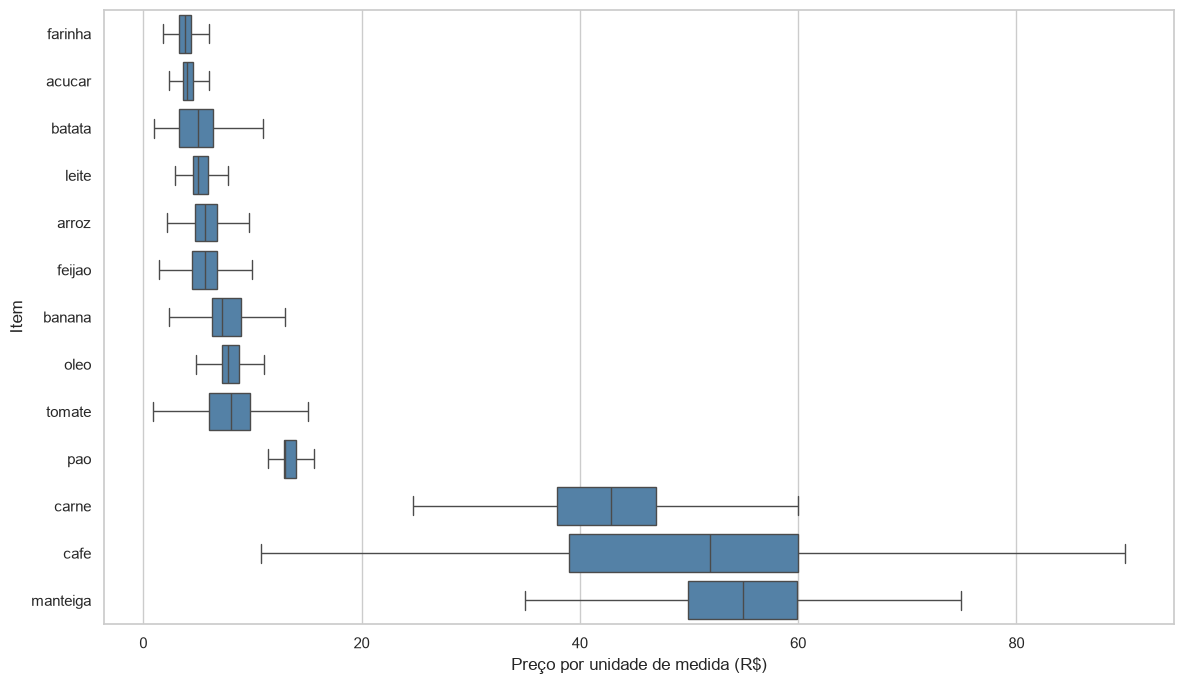

In [36]:
items_order = cesta_dieese_df.groupby("item")["preco_unitario"].median().sort_values().index

plt.figure(figsize=(12, 7))
sns.boxplot(data=cesta_dieese_df, x="preco_unitario", y="item", order=items_order, showfliers=False, color="steelblue")
plt.xlabel("Preço por unidade de medida (R$)")
plt.ylabel("Item")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/distribuicao_preco_por_item.png", dpi=150)
plt.show()


A mediana de preço varia bastante entre os itens: de cerca de 5 reais em batata, banana e leite até mais de 40 reais em carne, quase 9 vezes mais caro que o item mais barato da cesta. Arroz e açúcar também têm dispersão alta (desvio padrão acima de 8), puxada por diferenças de embalagem e marca que a seleção pelo subtipo da metodologia não elimina completamente. Leite e óleo, por sua vez, têm distribuição mais concentrada (desvio padrão abaixo de 1,1).

### 5.2. Redes com mais registros na amostra

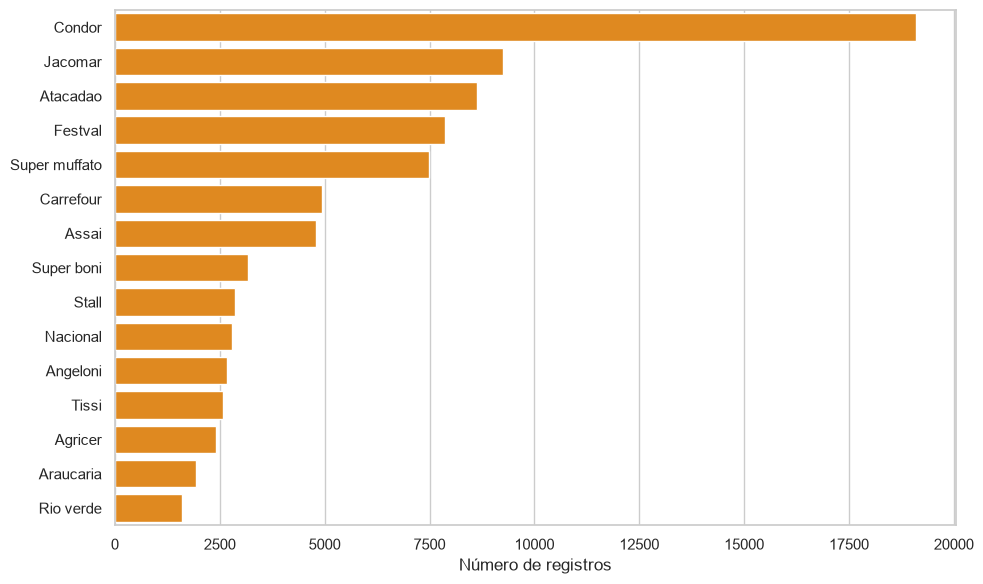

In [37]:
top_redes = cesta_dieese_df["rede_normalizada"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_redes.values, y=top_redes.index, color="darkorange")
plt.xlabel("Número de registros")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/top_redes.png", dpi=150)
plt.show()


### 5.3. Preço por unidade e tamanho de embalagem

Só arroz, açúcar e farinha têm mais de um tamanho de embalagem na cesta (os demais 10 itens aparecem só em um tamanho). Por isso o gráfico fica restrito a esses três, comparando o preço por grama entre o pacote de 1 kg e o de 5 kg (arroz também tem alguns registros de 2 kg).

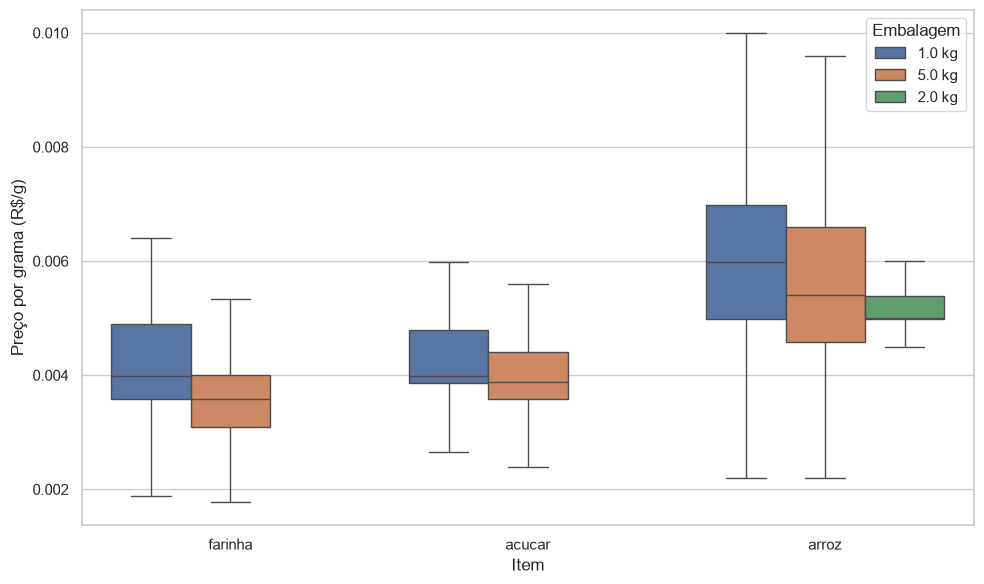

In [38]:
itens_com_variedade = cesta_dieese_df.groupby("item")["qtd_fracionamento"].nunique()
itens_com_variedade = itens_com_variedade[itens_com_variedade > 1].index

package_df = cesta_dieese_df[cesta_dieese_df["item"].isin(itens_com_variedade)].copy()
package_df["preco_por_unidade"] = package_df["preco_efetivo"] / package_df["qtd_fracionamento"]
package_df["embalagem_kg"] = (package_df["qtd_fracionamento"] / 1000).astype(str) + " kg"

plt.figure(figsize=(10, 6))
sns.boxplot(data=package_df, x="item", y="preco_por_unidade", hue="embalagem_kg", showfliers=False)
plt.xlabel("Item")
plt.ylabel("Preço por grama (R$/g)")
plt.legend(title="Embalagem")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/preco_por_unidade_embalagem.png", dpi=150)
plt.show()


Nos três itens, o pacote de 5 kg sai mais barato por grama que o de 1 kg: a diferença é maior em farinha (cerca de 10% mais barato no pacote grande) e menor em açúcar (cerca de 3%). O arroz tem um comportamento misto: o pacote de 2 kg, bem mais raro na amostra, aparece com o menor preço por grama dos três tamanhos, o que pode refletir menos promoções ou menos marcas competindo nesse formato específico, não necessariamente uma vantagem real de escala.

## 6. Cesta básica com produtos padronizados

Esta seção repete, sobre o dataset completo e de forma independente das seções 3 e 4, as mesmas decisões tomadas e justificadas: 
- Identidade do produto por `id_produto`
- Rede normalizada (sem typos ou multiplas ocorrencias da mesma rede)
- `preco_efetivo` com prioridade de promocao > regular > fidelidiade > atacado
- Remoção de registros sem preço
- Seleção dos itens e do subtipo pelo mesmo critério por `id_produto`
- Correção dos três casos de erro de digitação no fracionamento
- Corte em abril de 2023
- Remoção dos outliers por desvio padrão (k=3).

Nenhuma regra nova entra aqui: o objetivo é aplicar o que já foi validado na amostra ao dataset inteiro, recalculando sobre o dataset completo tudo que a seção 3 havia calculado sobre a amostra.

### 6.1. Preparação e seleção dos produtos

In [39]:
# mesma prioridade de precos da secao 3.5, declarada aqui para a secao nao depender dela
price_priority = ["preco_promocao", "preco_regular", "preco_fidelidade", "preco_atacado"]

# network_map: mesma logica de similaridade/substring da secao 3.3, recalculada sobre a contagem
# de redes do dataset completo (mais precisa que a da amostra, que pode nao conter alguma variante rara)
with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        network_counts = pd.read_csv(f, sep=";", usecols=["rede"])["rede"].value_counts().rename_axis("rede").reset_index(name="registros")

pairs = network_counts.merge(network_counts, how="cross", suffixes=("_a", "_b"))
pairs = pairs[pairs["rede_a"] < pairs["rede_b"]]
pairs["similarity"] = pairs.apply(lambda r: SequenceMatcher(None, r["rede_a"].lower(), r["rede_b"].lower()).ratio(), axis=1)
duplicates = pairs[pairs["similarity"] >= 0.85].copy()

sub_pairs = network_counts.merge(network_counts, how="cross", suffixes=("_a", "_b"))
sub_pairs = sub_pairs[sub_pairs["rede_a"] != sub_pairs["rede_b"]]
sub_pairs = sub_pairs[sub_pairs["rede_a"].str.len() >= 4]
substring_mask = sub_pairs.apply(lambda r: r["rede_a"].lower() in r["rede_b"].lower(), axis=1)
substrings = sub_pairs[substring_mask].copy()

# mesmas excecoes da secao 3.3: redes distintas, mesmo com alta similaridade/substring
exceptions = [("Tok super", "Top super"), ("Supermercado curitiba", "Supermercado italia")]

# mesmas fusoes forcadas da secao 3.3: erro de digitacao confirmado manualmente, mas que o
# SequenceMatcher nao capta por serem nomes curtos (a troca de 1-2 caracteres pesa mais na
# razao de similaridade de palavras curtas). A quantidade pequena de redes (100 no conjunto
# completo) permitiu revisar manualmente a lista completa apos a normalizacao automatica e
# encontrar esses casos que o codigo nao capturou.
forced_merges = {
    "Assaa": "Assai",
    "Telaamaco": "Telemaco",
    "Super telamaco": "Telemaco",
    "Boni bacacheri": "Boni supermercado",
    "Boni supermercado": "Super boni",
    "Max muffato": "Max atacadista",
}

def is_exception(row):
    pair = (row["rede_a"], row["rede_b"])
    return pair in exceptions or pair[::-1] in exceptions

valid_duplicates = duplicates[~duplicates.apply(is_exception, axis=1)]
valid_substrings = substrings[~substrings.apply(is_exception, axis=1)]

def pair_to_mapping(row):
    if row["registros_a"] >= row["registros_b"]:
        return row["rede_b"], row["rede_a"]
    return row["rede_a"], row["rede_b"]

similarity_pairs = valid_duplicates.apply(pair_to_mapping, axis=1, result_type="expand")
similarity_pairs.columns = ["variant", "canonical"]
substring_pairs = valid_substrings.apply(pair_to_mapping, axis=1, result_type="expand")
substring_pairs.columns = ["variant", "canonical"]
mapping_df = pd.concat([similarity_pairs, substring_pairs], ignore_index=True)
network_map = dict(zip(mapping_df["variant"], mapping_df["canonical"]))
network_map.update(forced_merges)

# resolve cadeias (ex.: Boni bacacheri -> Boni supermercado -> Super boni) para o canonico final
for variant in list(network_map):
    target = network_map[variant]
    while target in network_map and network_map[target] != target:
        target = network_map[target]
    network_map[variant] = target

print(f"network_map: {len(network_map)} mapeamentos encontrados")
print("Substituicoes de rede aplicadas (variante -> canonico), para revisao manual:")
for variant, canonical in sorted(network_map.items()):
    print(f"  {variant!r} -> {canonical!r}")

# mesma lista e regex da secao 3.6, aplicada ao dataset completo via chunks
cesta_items = [
    "carne", "leite", "feijao", "arroz", "farinha", "batata",
    "tomate", "pao", "cafe", "banana", "acucar", "oleo", "manteiga",
]
item_pattern = r"^(" + "|".join(cesta_items) + r")"

read_columns = ["data_pesquisa", "rede", "id_produto", "descricao"] + price_priority

# primeira passada: so para montar o mapa id_produto -> item (mesmo raciocinio da secao 3.6,
# recupera linhas com erro de digitacao do mesmo produto que outra linha identificou corretamente)
product_item_parts = []
with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000, usecols=read_columns):
            chunk["descricao_lower"] = chunk["descricao"].str.lower()
            item_by_description = chunk["descricao_lower"].str.extract(item_pattern)[0]
            product_item_parts.append(pd.DataFrame({"id_produto": chunk["id_produto"], "item": item_by_description}).dropna(subset=["item"]))

product_item = (
    pd.concat(product_item_parts, ignore_index=True)
    .drop_duplicates(subset=["id_produto"])
    .set_index("id_produto")["item"]
)
del product_item_parts

# segunda passada: reabre o arquivo e filtra cada chunk pelo mapa id_produto -> item, sem manter
# o dataset completo em memoria entre as duas passadas (chunksize existe para isso)
selected_chunks = []
with zipfile.ZipFile(DATASET_ZIP) as z:
    with z.open(CSV_NAME) as f:
        for chunk in pd.read_csv(f, sep=";", chunksize=500_000, usecols=read_columns):
            selected_chunks.append(chunk[chunk["id_produto"].isin(product_item.index)].copy())

df_cesta = pd.concat(selected_chunks, ignore_index=True)
df_cesta["item"] = df_cesta["id_produto"].map(product_item)
df_cesta["data_pesquisa"] = pd.to_datetime(df_cesta["data_pesquisa"], errors="coerce")
df_cesta["descricao_lower"] = df_cesta["descricao"].str.lower()

del selected_chunks

print(f"\nProdutos selecionados: {df_cesta['id_produto'].nunique():,}")
print(f"Registros selecionados: {len(df_cesta):,}")
df_cesta.groupby("item").agg(produtos=("id_produto", "nunique"), registros=("id_produto", "size"))


network_map: 26 mapeamentos encontrados
Substituicoes de rede aplicadas (variante -> canonico), para revisao manual:
  'Arauca!ria' -> 'Araucaria'
  'Armazem da maria atacadista' -> 'Armazem da maria'
  'Assaa' -> 'Assai'
  'Assai atacadista' -> 'Assai'
  'Atacadao atacadista' -> 'Atacadao'
  'Atacadapso' -> 'Atacadao'
  'Boni bacacheri' -> 'Super boni'
  'Boni supermercado' -> 'Super boni'
  'Circuito atacadista' -> 'Circuito'
  'Condor joao bettega' -> 'Condor'
  'Condor joapso bettega' -> 'Condor'
  'Festival' -> 'Festval'
  'Gigante atacadista' -> 'Gigante'
  'Hipermercado condor novo mundo' -> 'Condor'
  'Max muffato' -> 'Max atacadista'
  'Nogueira' -> 'Supermercado nogueira'
  'Sacolao popular ' -> 'Sacolao popular'
  'Super telamaco' -> 'Telemaco'
  'Supermercado galvapso' -> 'Supermercado galvao'
  'Supermercado nacional' -> 'Nacional'
  'Supermercados agricer' -> 'Agricer'
  'Supermercados araucaria' -> 'Araucaria'
  'Supermercados colatusso' -> 'Colatusso'
  'Telaamaco' -> '


Produtos selecionados: 463
Registros selecionados: 1,267,450


,produtos,registros
item,,
acucar,38,106657
arroz,54,179009
banana,8,36073
batata,19,45349
cafe,29,86095
carne,45,162652
farinha,84,150525
feijao,29,91867
leite,84,218938


### 6.2. Rede, preço efetivo e corte de data

Mesmas regras da seção 3: `rede_normalizada` usando o mapeamento já calculado em 3.3, `preco_efetivo` com a mesma prioridade de preços, remoção de registros sem nenhum preço preenchido e corte para registros a partir de abril de 2023 (seção 3.6, já que antes disso não há marca nem tamanho de embalagem).

In [40]:
# rede_normalizada: mesmo mapeamento calculado na secao 3.3, sobre o dataset completo
df_cesta["rede_normalizada"] = df_cesta["rede"].replace(network_map)

# preco_efetivo: mesma prioridade da secao 3.5
df_cesta["preco_efetivo"] = df_cesta[price_priority].replace(0, np.nan).bfill(axis=1).iloc[:, 0]

# remove registros sem nenhum preco preenchido (secao 3.5: mantidos na exploracao, mas devem
# ser removidos aqui, onde o preco e usado diretamente no calculo de custo da cesta)
before_price_filter = len(df_cesta)
df_cesta = df_cesta.dropna(subset=["preco_efetivo"]).reset_index(drop=True)
print(f"Registros sem preco removidos: {before_price_filter - len(df_cesta):,}")

# corte de data (secao 3.6): antes de abril/2023 a pesquisa nao registrava marca nem tamanho
before_date_cutoff = len(df_cesta)
df_cesta = df_cesta[df_cesta["data_pesquisa"] >= "2023-04-01"].reset_index(drop=True)
print(f"Registros antes de abril/2023 removidos: {before_date_cutoff - len(df_cesta):,}")
print(f"Registros restantes: {len(df_cesta):,}")


Registros sem preco removidos: 33
Registros antes de abril/2023 removidos: 237,005
Registros restantes: 1,030,412


### 6.3. Fracionamento

Mesma extração de `qtd_fracionamento`/`unidade_fracionamento` da seção 3.6, com as três correções de erro de digitação (1 gr/1 ml tratados como 1 kg/1 litro, 5 gr tratado como 5 kg, "- -kg" sem número tratado como 1 kg), e os campos `descricao_norm`/`tipo` da seção 3.7, necessários para aplicar o filtro de subtipo a seguir.

In [41]:
# mesmo size_pattern com grupos de captura da secao 3.6
size_pattern_groups = r"-\s*(\d+(?:[.,]\d+)?)?\s*(kg|gr|ml|litro|l)$"

df_cesta["descricao_norm"] = df_cesta["descricao_lower"].str.replace(r"\s+", " ", regex=True).str.strip()

package_size = df_cesta["descricao_norm"].str.extract(size_pattern_groups)
raw_value = package_size[0].str.replace(",", ".", regex=False).astype(float)
raw_unit = package_size[1]

is_weight = raw_unit.isin(["kg", "gr"])
is_volume = raw_unit.isin(["litro", "l", "ml"])

# tres correcoes de erro de digitacao (secao 3.6)
likely_kg_typo = (raw_unit == "gr") & raw_value.isin([1, 5])
likely_liter_typo = (raw_unit == "ml") & (raw_value == 1)
missing_value_typo = raw_unit.isin(["kg", "litro", "l"]) & raw_value.isna()
raw_value = raw_value.where(~missing_value_typo, 1.0)

conversion_factor = pd.Series(1.0, index=df_cesta.index)
conversion_factor[raw_unit == "kg"] = 1000
conversion_factor[raw_unit.isin(["litro", "l"])] = 1000
conversion_factor[likely_kg_typo] = 1000
conversion_factor[likely_liter_typo] = 1000

df_cesta["qtd_fracionamento"] = raw_value * conversion_factor
df_cesta["unidade_fracionamento"] = np.where(is_weight, "g", np.where(is_volume, "ml", None))

# tipo (secao 3.7): texto antes da marca, usado pelo filtro de subtipo DIEESE a seguir
df_cesta["tipo"] = df_cesta["descricao_norm"].str.replace(r"\(\s*\+\s*\)\s*barato", "", regex=True).str.split(" -").str[0].str.strip(" .")

sem_fracionamento = df_cesta["qtd_fracionamento"].isna().sum()
print(f"Registros sem fracionamento identificado: {sem_fracionamento:,} ({100 * sem_fracionamento / len(df_cesta):.2f}%)")


Registros sem fracionamento identificado: 0 (0.00%)


### 6.4. Seleção do subtipo

Como na seção 3.7, o filtro é decidido por `id_produto`, não por linha, para que um erro de digitação não exclua parte dos registros de um produto já incluído.

In [42]:
# mesmo dicionario da secao 3.7
# cafe: a vacuo = cafe em po no varejo (torrado e moido, embalado a vacuo); ver comentario
# equivalente na secao 3.7
dieese_subtype_pattern = {
    "carne": r"^carne bovina (?:coxao mole|patinho|posta vermelha)\b",
    "leite": r"^leite (?:longa vida integral|pasteurizado integral|integral)\b",
    "feijao": r"^feijao preto\b",
    "arroz": r"^arroz polido\b(?!.*agulhinha)",
    "farinha": r"^farinha de trigo\b(?!.*(?:integral|especial|premium))",
    "batata": r"^batata monalisa\b",
    "tomate": r"^tomate (?:longa vida|rasteiro)\b",
    "pao": r"^pao frances\b",
    "cafe": r"^cafe (?:a vacuo|vacuo)\b(?!.*(?:soluvel|artesanal))",
    "banana": r"^banana (?:caturra|prata)\b",
    "acucar": r"^acucar refinado\b(?!.*extra fino)",
    "oleo": r"^oleo de soja\b",
    "manteiga": r"^manteiga\b(?!.*(?:0%|zero) lactose)",
}

dieese_product_ids = set()
for item, pattern in dieese_subtype_pattern.items():
    item_rows = df_cesta["item"] == item
    matches = item_rows & df_cesta["descricao_norm"].str.contains(pattern, regex=True, na=False)
    dieese_product_ids.update(df_cesta.loc[matches, "id_produto"].unique())

before_dieese_filter = len(df_cesta)
df_cesta = df_cesta[df_cesta["id_produto"].isin(dieese_product_ids)].reset_index(drop=True)
print(f"Registros removidos: {before_dieese_filter - len(df_cesta):,}")
print(f"Registros restantes: {len(df_cesta):,}")

df_cesta.groupby("item").agg(produtos=("id_produto", "nunique"), registros=("id_produto", "size"))


Registros removidos: 556,232
Registros restantes: 474,180


,produtos,registros
item,,
acucar,11,50013
arroz,27,74454
banana,2,18006
batata,1,9462
cafe,17,63042
carne,3,22769
farinha,33,69186
feijao,12,37283
leite,13,50674


### 6.5. Preço por unidade de medida

Calcular o desvio padrão sobre `preco_efetivo` (preço do pacote inteiro) mistura embalagens de tamanhos diferentes do mesmo item: arroz, açúcar e farinha têm pacotes de 1 kg, 2 kg e 5 kg, e um pacote de 5 kg custa naturalmente bem mais que um de 1 kg, sem isso ser um preço anômalo. Essa mistura infla o desvio padrão desses três itens o suficiente para que nenhum registro seja identificado como outlier neles.

Usar o `preco_unitario` (preço por quilo ou litro, já dividido pelo tamanho da embalagem) na detecção de outliers (seção 6.6) elimina esse efeito: pacotes de tamanhos diferentes do mesmo item passam a ter preços comparáveis entre si.

In [43]:
# converte para kg ou litro (preco_efetivo e cobrado pelo pacote inteiro, nao por grama/ml)
df_cesta["quantidade"] = df_cesta["qtd_fracionamento"] / 1000
df_cesta["preco_unitario"] = df_cesta["preco_efetivo"] / df_cesta["quantidade"]

# para banana usa-se o prefixo de "tipo" (nao o texto completo) para o multiplicador nao falhar
# silenciosamente caso "tipo" venha com sufixo extra (ex.: "banana prata especial")
banana_prefix_multiplier = {"caturra": 1.8, "prata": 1.2}
is_banana = df_cesta["item"] == "banana"
banana_prefix = df_cesta.loc[is_banana, "tipo"].str.extract(r"^banana (caturra|prata)")[0]
multiplier = banana_prefix.map(banana_prefix_multiplier)

sem_multiplicador = multiplier.isna().sum()
if sem_multiplicador:
    print(f"Aviso: {sem_multiplicador} registros de banana sem multiplicador aplicavel (tipo fora de caturra/prata)")

# preco_unitario de banana passa a ser preco por DUZIA (nao mais R$/kg)
df_cesta.loc[is_banana, "preco_unitario"] = df_cesta.loc[is_banana, "preco_unitario"] * multiplier

df_cesta["ano_mes"] = df_cesta["data_pesquisa"].dt.to_period("M")

df_cesta.groupby("item")["preco_unitario"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
item,,,,,,,,
acucar,50013.0,4.10,0.66,2.20,3.60,3.99,4.60,6.99
arroz,74454.0,5.83,1.44,0.98,4.79,5.69,6.95,10.99
banana,18006.0,7.80,2.26,1.07,6.35,7.19,8.98,16.18
batata,9462.0,5.12,2.37,0.89,3.29,4.89,6.49,14.99
cafe,63042.0,49.70,14.04,10.78,38.58,51.96,59.96,91.98
carne,22769.0,42.95,7.98,14.41,37.90,42.90,46.98,83.59
farinha,69186.0,3.88,0.85,0.70,3.29,3.79,4.39,7.69
feijao,37283.0,5.71,1.53,0.04,4.49,5.69,6.78,12.98
leite,50674.0,5.23,0.97,1.99,4.59,4.99,5.89,14.70


### 6.6. Remoção de outliers

Mesmo critério da seção 4: desvio padrão com multiplicador 3, calculado sobre o preço por unidade de medida (não mais sobre o preço do pacote) e aplicado por item, removendo definitivamente os registros fora da faixa.

In [44]:
STD_K = 3

stats_std = df_cesta.groupby("item")["preco_unitario"].agg(media="mean", desvio="std")
stats_std["floor"] = stats_std["media"] - STD_K * stats_std["desvio"]
stats_std["ceiling"] = stats_std["media"] + STD_K * stats_std["desvio"]

df_cesta = df_cesta.merge(stats_std[["floor", "ceiling"]], left_on="item", right_index=True)
outlier_mask = (df_cesta["preco_unitario"] < df_cesta["floor"]) | (df_cesta["preco_unitario"] > df_cesta["ceiling"])

before_outlier_removal = len(df_cesta)
df_cesta = df_cesta[~outlier_mask].drop(columns=["floor", "ceiling"]).reset_index(drop=True)
print(f"Outliers removidos (desvio padrão sobre preço unitário, k=3): {before_outlier_removal - len(df_cesta):,}")
print(f"Registros restantes: {len(df_cesta):,}")

Outliers removidos (desvio padrão sobre preço unitário, k=3): 1,862
Registros restantes: 472,318


### 6.7. Preço por unidade de medida ao longo do tempo

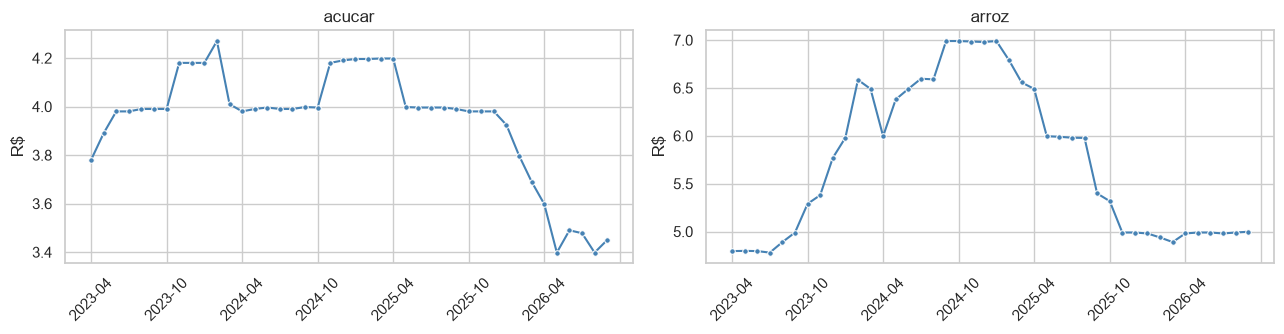

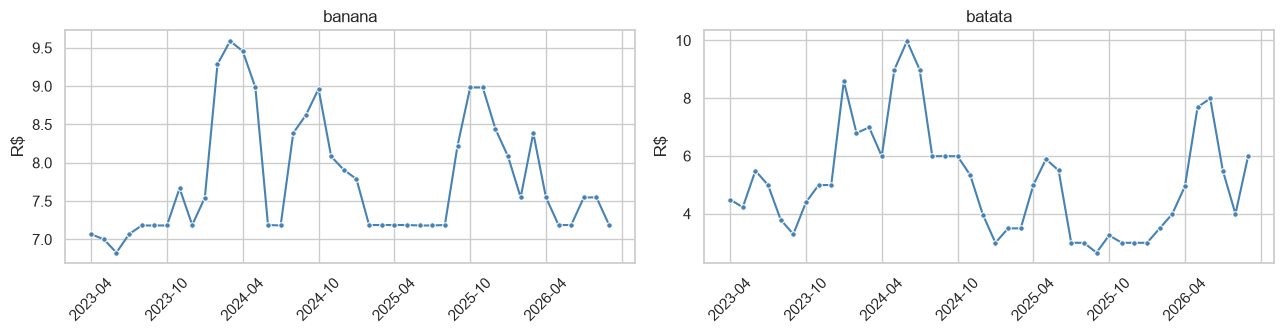

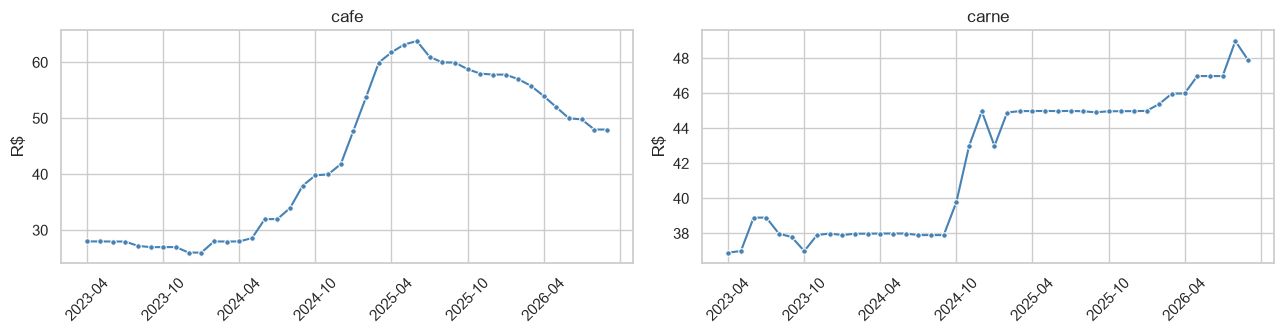

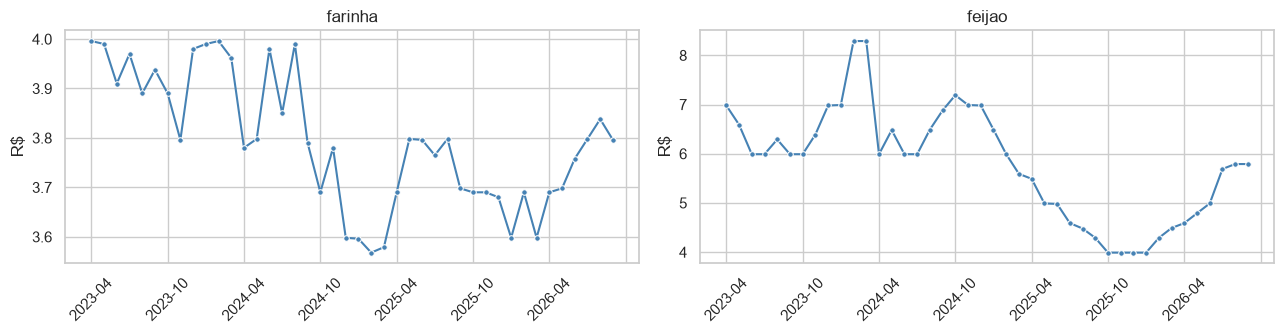

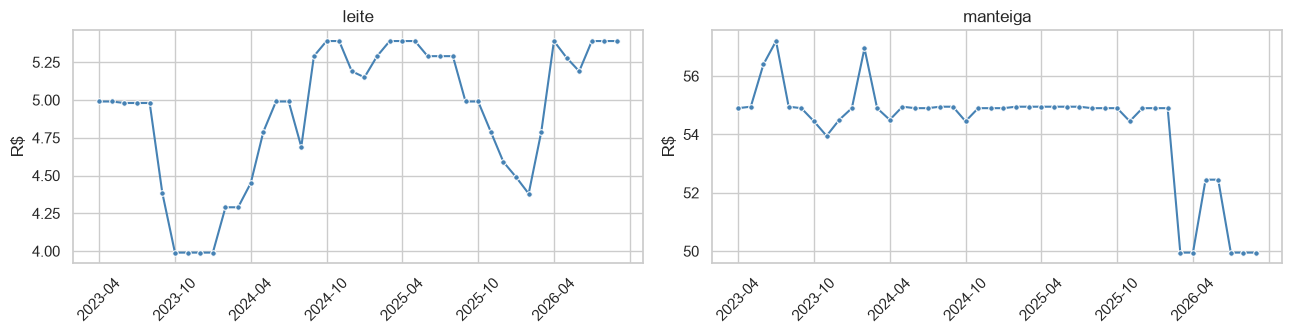

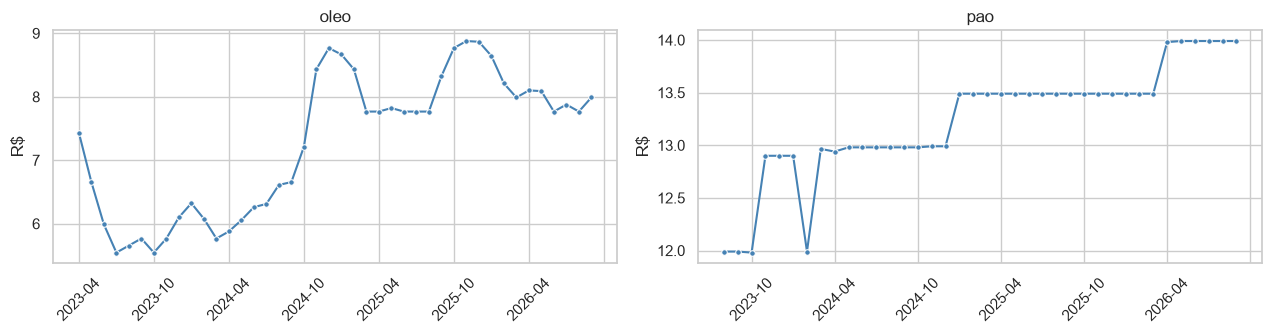

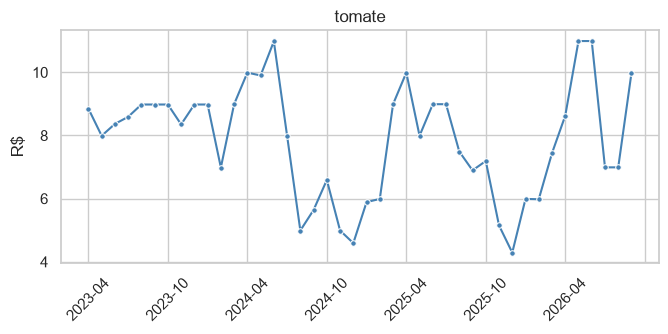

,primeiro_mes_disponivel,preco_no_primeiro_mes,ultimo_mes,maximo,mes_do_maximo
item,,,,,
acucar,2023-04,3.78,3.45,4.27,2024-02
arroz,2023-04,4.80,5.00,6.99,2024-09
banana,2023-04,7.07,7.19,9.59,2024-03
batata,2023-04,4.49,5.99,9.98,2024-06
cafe,2023-04,27.98,47.98,63.80,2025-06
carne,2023-04,36.90,47.90,48.98,2026-08
farinha,2023-04,4.00,3.80,4.00,2023-04
feijao,2023-04,6.98,5.79,8.29,2024-02
leite,2023-04,4.99,5.39,5.39,2024-10


In [45]:
monthly_unit_price = df_cesta.groupby(["ano_mes", "item"])["preco_unitario"].median().unstack("item")

items = monthly_unit_price.columns.tolist()
n_cols = 2

# cada par de itens vira uma figura separada, salva em um arquivo proprio
for i in range(0, len(items), n_cols):
    pair = items[i:i + n_cols]
    fig, axes = plt.subplots(1, n_cols, figsize=(13, 3.5))
    for ax, item in zip(axes, pair):
        serie = monthly_unit_price[item].reset_index(name="preco")
        serie["ano_mes"] = serie["ano_mes"].astype(str)
        sns.lineplot(data=serie, x="ano_mes", y="preco", marker="o", markersize=4, color="steelblue", ax=ax)
        ax.set_title(item)
        ax.set_xlabel("")
        ax.set_ylabel("R$")
        ax.tick_params(axis="x", rotation=45)
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=8))
    # esconde o segundo eixo se o par tiver so 1 item (ultimo grupo, numero impar de itens)
    for ax in axes[len(pair):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{IMAGES_DIR}/cesta_preco_por_unidade_{'_'.join(pair)}.png", dpi=150)
    plt.show()

# iloc[0] pegaria sempre abril/2023 para todos os itens, mas pao so tem dado a partir de
# agosto/2023; first_valid_index encontra o primeiro mes com dado real, por item
first_valid_month = monthly_unit_price.apply(lambda col: col.first_valid_index())
first_valid_price = monthly_unit_price.apply(lambda col: col.loc[col.first_valid_index()])

pd.DataFrame({
    "primeiro_mes_disponivel": first_valid_month.astype(str),
    "preco_no_primeiro_mes": first_valid_price,
    "ultimo_mes": monthly_unit_price.iloc[-1],
    "maximo": monthly_unit_price.max(),
    "mes_do_maximo": monthly_unit_price.idxmax().astype(str),
}).round(2)


### 6.8. Custo da cesta

Quantidades mensais do Decreto-Lei 399/1938 para a Região 3 (inclui o Paraná):

- **Carne**: 6,6 kg
- **Leite**: 7,5 l
- **Feijão**: 4,5 kg
- **Arroz**: 3,0 kg
- **Farinha**: 1,5 kg
- **Batata**: 6,0 kg
- **Tomate**: 9,0 kg
- **Pão**: 6,0 kg
- **Café**: 0,6 kg
- **Banana**: 90 unidades = 7,5 dúzias (`preco_unitario` já está em R$/dúzia, seção 6.6)
- **Açúcar**: 3,0 kg
- **Óleo**: 0,9 l
- **Manteiga**: 0,75 kg

O dataset não tem nenhum registro de pão francês com tamanho de embalagem reconhecido entre abril e julho de 2023. Nesse período, o custo da cesta é calculado com no mínimo 12 dos 13 itens disponíveis no mês, isso subestima levemente o custo real nesses quatro meses, já que falta a contribuição do pão.

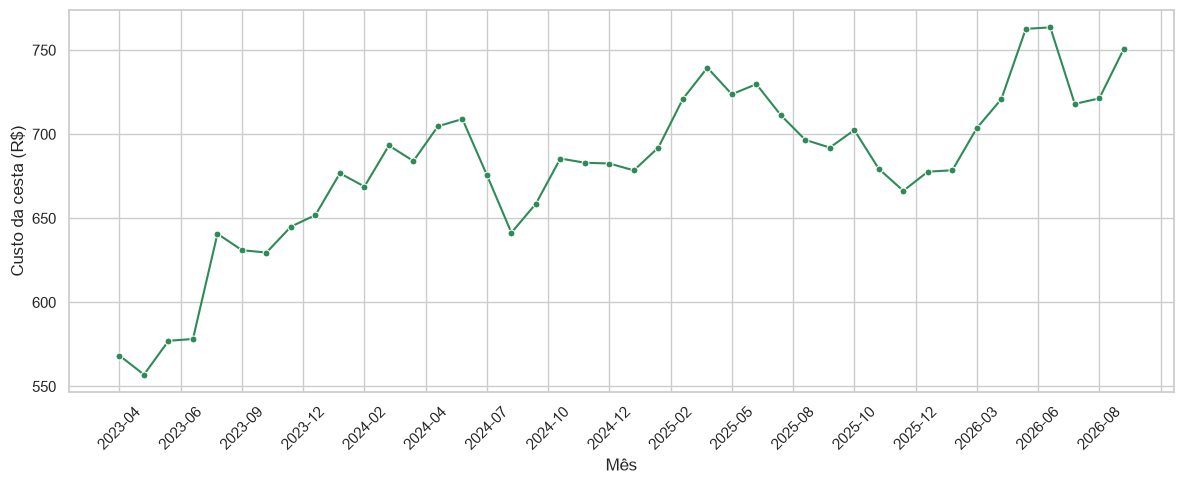

Primeiro mês (2023-04): R$ 568.35
Pico (2026-06): R$ 763.54
Último mês (2026-09): R$ 750.71


In [46]:
cesta_quantities = pd.Series({
    "carne": 6.6, "leite": 7.5, "feijao": 4.5, "arroz": 3.0, "farinha": 1.5,
    "batata": 6.0, "tomate": 9.0, "pao": 6.0, "cafe": 0.6, "banana": 90 / 12,  # 7.5 duzias
    "acucar": 3.0, "oleo": 0.9, "manteiga": 0.75,
})

city_cost = (monthly_unit_price * cesta_quantities).sum(axis=1, min_count=12)

city_cost_df = city_cost.rename("custo").reset_index()
city_cost_df["ano_mes"] = city_cost_df["ano_mes"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=city_cost_df, x="ano_mes", y="custo", marker="o", markersize=5, color="seagreen")
plt.xlabel("Mês")
plt.ylabel("Custo da cesta (R$)")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=20))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_custo_mensal.png", dpi=150)
plt.show()

print(f"Primeiro mês ({city_cost.index[0]}): R$ {city_cost.iloc[0]:.2f}")
print(f"Pico ({city_cost.idxmax()}): R$ {city_cost.max():.2f}")
print(f"Último mês ({city_cost.index[-1]}): R$ {city_cost.iloc[-1]:.2f}")


### 6.9. Contribuição de cada item para a variação do custo (período completo)

Como o custo da cesta é a soma de `preco_unitario x quantidade` de cada item, a contribuição de cada item para a variação de um mês para o outro é exatamente `preco_unitario x quantidade`. O gráfico abaixo decompõe a variação entre agosto de 2023 (primeiro mês com os 13 itens disponíveis) e o fim da série.

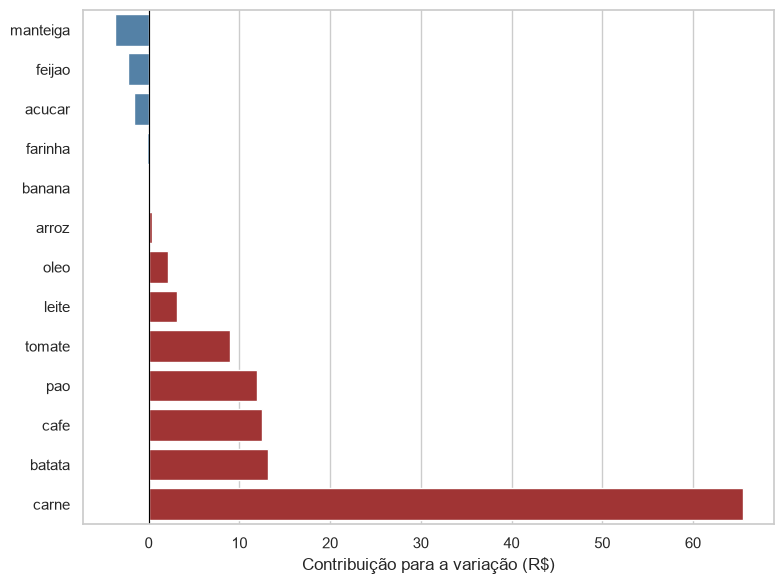

In [47]:
variacao_mensal = monthly_unit_price.diff().multiply(cesta_quantities)

def grafico_contribuicao(ax, inicio, fim, titulo):
    contrib = variacao_mensal.loc[inicio:fim].sum().sort_values()
    cores = ["firebrick" if v > 0 else "steelblue" for v in contrib.values]
    sns.barplot(x=contrib.values, y=contrib.index, hue=contrib.index, palette=cores, legend=False, ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Contribuição para a variação (R$)")
    ax.set_ylabel("")

fig, ax = plt.subplots(figsize=(8, 6))
grafico_contribuicao(ax, "2023-09", "2026-09", "Agosto/2023 a setembro/2026")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_contribuicao_periodo_completo.png", dpi=150)
plt.show()


### 6.10. Custo da cesta por rede

A comparaçao exige pelo menos `MIN_RECORDS_PER_ITEM` registros de cada um dos 13 itens por rede, para a mediana de preço não ficar instável com poucos pontos isso exclui as redes de menor volume na pesquisa, que não necessariamente têm o mesmo perfil de preço das redes maiores.

Redes elegiveis: 29 de 45 (64.4% do total nos ultimos 12 meses)


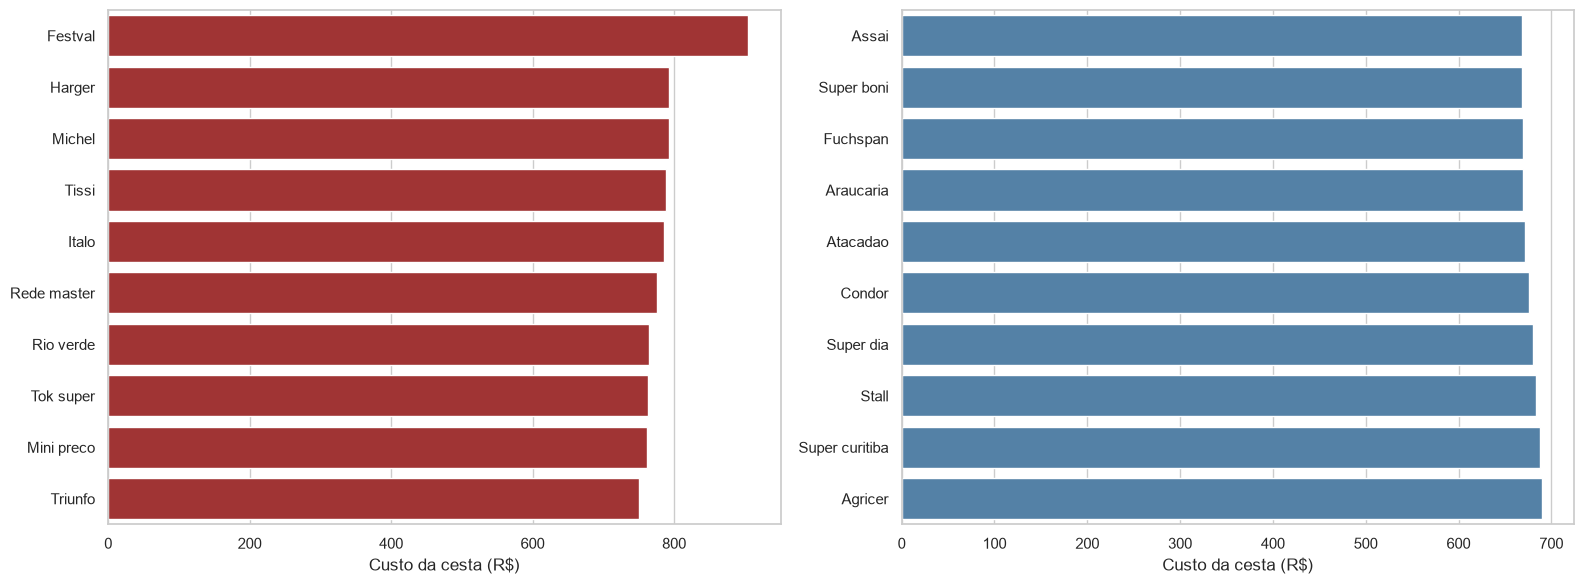

Período: 2025-10 a 2026-09
Redes com os 13 itens: 29
Mais barata: Assai (R$ 668.47)
Mais cara: Festval (R$ 905.13)
Diferença: 35.4%


In [48]:
last_month = df_cesta["ano_mes"].max()
df_recent = df_cesta[df_cesta["ano_mes"] > last_month - 12].copy()

records_per_item = df_recent.groupby(["rede_normalizada", "item"]).size().unstack("item").fillna(0)
MIN_RECORDS_PER_ITEM = 20
eligible_networks = records_per_item[(records_per_item >= MIN_RECORDS_PER_ITEM).all(axis=1)].index

total_redes = df_recent["rede_normalizada"].nunique()
print(f"Redes elegiveis: {len(eligible_networks)} de {total_redes} "
      f"({100 * len(eligible_networks) / total_redes:.1f}% do total nos ultimos 12 meses)")

network_unit_price = (
    df_recent[df_recent["rede_normalizada"].isin(eligible_networks)]
    .groupby(["rede_normalizada", "item"])["preco_unitario"].median().unstack("item")
)
network_cost = (network_unit_price * cesta_quantities).sum(axis=1).sort_values()

mais_caras = network_cost.tail(10).sort_values(ascending=False)
mais_baratas = network_cost.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=mais_caras.values, y=mais_caras.index, color="firebrick", ax=axes[0])
axes[0].set_xlabel("Custo da cesta (R$)")
axes[0].set_ylabel("")
sns.barplot(x=mais_baratas.values, y=mais_baratas.index, color="steelblue", ax=axes[1])
axes[1].set_xlabel("Custo da cesta (R$)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_custo_por_rede.png", dpi=150)
plt.show()

print(f"Período: {df_recent['ano_mes'].min()} a {last_month}")
print(f"Redes com os 13 itens: {len(network_cost)}")
print(f"Mais barata: {network_cost.index[0]} (R$ {network_cost.iloc[0]:.2f})")
print(f"Mais cara: {network_cost.index[-1]} (R$ {network_cost.iloc[-1]:.2f})")
print(f"Diferença: {100 * (network_cost.iloc[-1] / network_cost.iloc[0] - 1):.1f}%")


### 6.11. Por que a Festval é a rede mais cara

A seção 6.10 mostrou a Festval como a rede mais cara entre as elegíveis. Para entender por quê, o gráfico abaixo decompõe o custo por item: para cada um dos 13 itens, mostra o preço mediano por unidade de medida da Festval contra a mediana das demais redes elegíveis, nos mesmos últimos 12 meses.

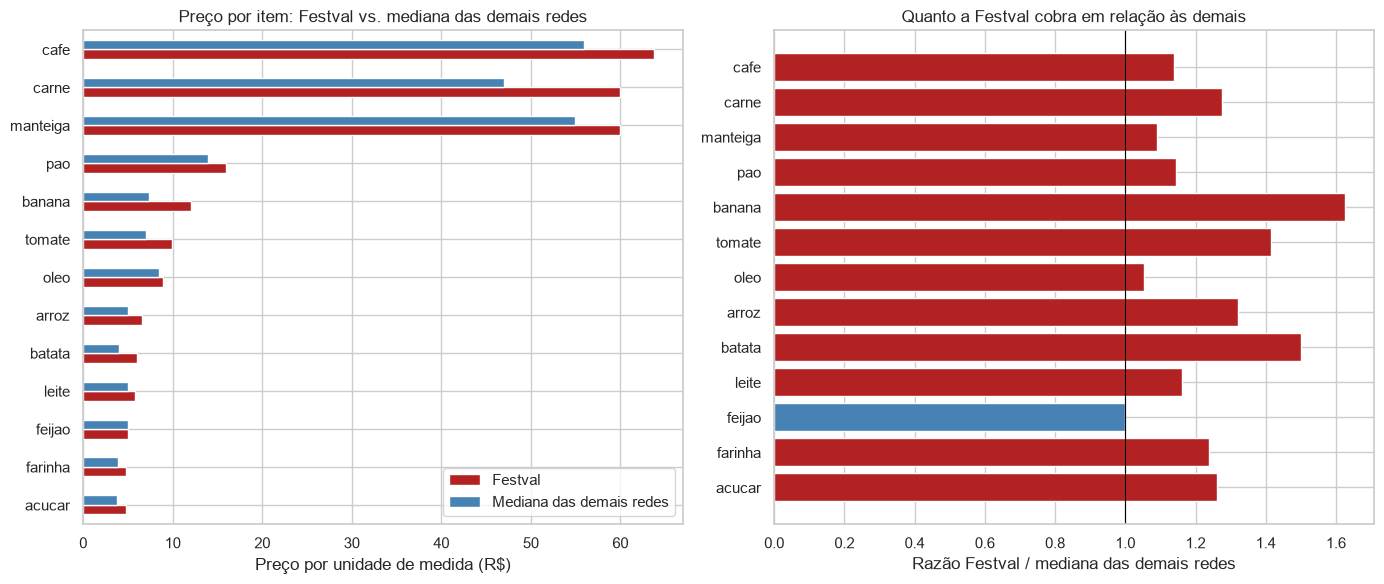

Itens em que a Festval cobra mais que a mediana das demais redes:


,Festval,Mediana das demais redes,razao
item,,,
acucar,4.79,3.80,1.26
farinha,4.79,3.87,1.24
leite,5.79,4.99,1.16
batata,5.99,3.99,1.50
arroz,6.60,4.99,1.32
oleo,8.87,8.41,1.05
tomate,9.90,6.99,1.42
banana,11.99,7.37,1.63
pao,15.99,13.98,1.14


In [49]:
festval_unit_price = network_unit_price.loc["Festval"]
median_unit_price = network_unit_price.drop(index="Festval").median()

comparacao = pd.DataFrame({
    "Festval": festval_unit_price,
    "Mediana das demais redes": median_unit_price,
}).sort_values("Festval")

comparacao["razao"] = comparacao["Festval"] / comparacao["Mediana das demais redes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparacao[["Festval", "Mediana das demais redes"]].plot(
    kind="barh", ax=axes[0], color=["firebrick", "steelblue"]
)
axes[0].set_xlabel("Preço por unidade de medida (R$)")
axes[0].set_ylabel("")
axes[0].set_title("Preço por item: Festval vs. mediana das demais redes")

cores = ["firebrick" if v > 1 else "steelblue" for v in comparacao["razao"]]
axes[1].barh(comparacao.index, comparacao["razao"], color=cores)
axes[1].axvline(1, color="black", linewidth=0.8)
axes[1].set_xlabel("Razão Festval / mediana das demais redes")
axes[1].set_title("Quanto a Festval cobra em relação às demais")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_festval_comparacao_item.png", dpi=150)
plt.show()

print("Itens em que a Festval cobra mais que a mediana das demais redes:")
display(comparacao[comparacao["razao"] > 1].round(2))


### 6.12. Evolução do custo da cesta nas maiores redes

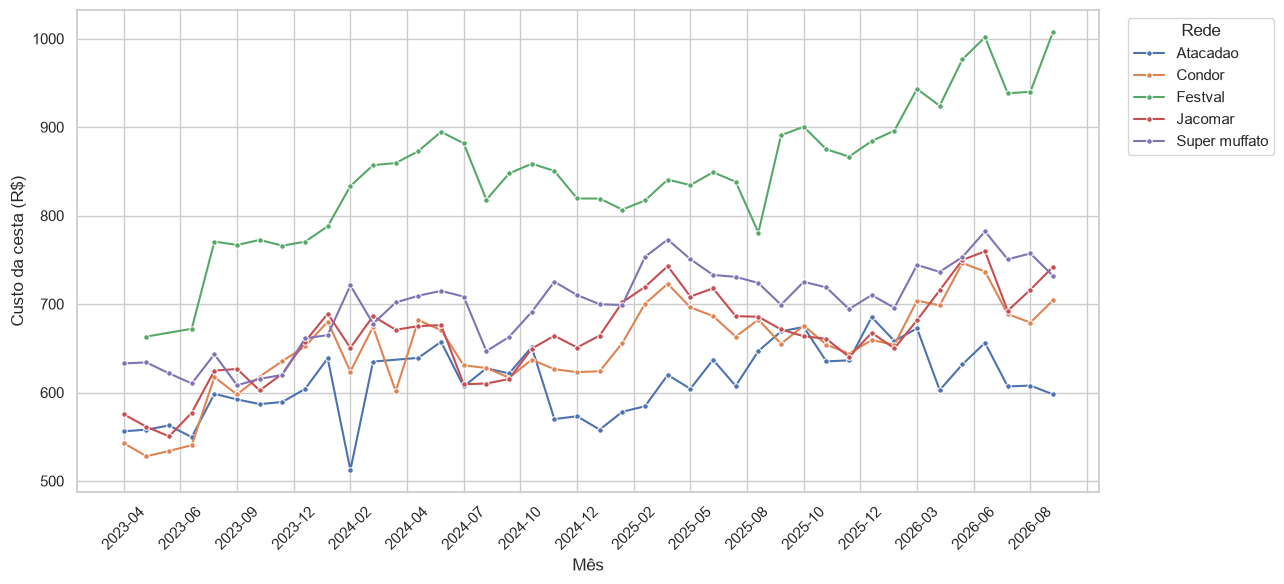

Redes incluídas (ordenadas por número de registros):
  Condor: 83,112 registros
  Jacomar: 40,677 registros
  Atacadao: 38,828 registros
  Festval: 34,662 registros
  Super muffato: 33,112 registros


In [50]:
top5_redes = df_cesta["rede_normalizada"].value_counts().head(5).index

monthly_unit_price_top5 = (
    df_cesta[df_cesta["rede_normalizada"].isin(top5_redes)]
    .groupby(["ano_mes", "rede_normalizada", "item"])["preco_unitario"].median()
    .unstack("item")
)

# min_count=12, mesma razao da secao 6.8: pao so tem dado a partir de agosto/2023
city_cost_top5 = (monthly_unit_price_top5 * cesta_quantities).sum(axis=1, min_count=12).unstack("rede_normalizada")

city_cost_top5_df = city_cost_top5.reset_index().melt(id_vars="ano_mes", var_name="rede", value_name="custo")
city_cost_top5_df["ano_mes"] = city_cost_top5_df["ano_mes"].astype(str)

plt.figure(figsize=(13, 6))
sns.lineplot(data=city_cost_top5_df, x="ano_mes", y="custo", hue="rede", marker="o", markersize=4)
plt.xlabel("Mês")
plt.ylabel("Custo da cesta (R$)")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=20))
plt.xticks(rotation=45)
plt.legend(title="Rede", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cesta_custo_top5_redes.png", dpi=150)
plt.show()

print("Redes incluídas (ordenadas por número de registros):")
for rede in top5_redes:
    print(f"  {rede}: {(df_cesta['rede_normalizada'] == rede).sum():,} registros")
